# **Pattern Recognition: Lab 2 – "Music Genre Recognition and Affective Music Analysis"**

---

## **Course Overview**

This project is developed in the context of the **School of Electrical and Computer Engineering (ECE), NTUA (Semester: Autumn 2025–2026)**.  
- **Course Name:** Pattern Recognition  
- **Instructor:** Alexandros Potamianos  
- **Platform:** Kaggle (GPU-accelerated kernels)  
- **Datasets:**  
  - **FMA Genre Spectrograms** (3834 clips, 20 music genres)  
  - **Multitask Affective Music Dataset** (1497 clips with valence, energy, danceability annotations)

---

### **Team Overview**

Our team consists of the following members:  
- **Peppas Michail-Athanasios** | 03121026  
- **Augerinos Panagiotis** | 03121023  

---

### **Project Scope**

This assignment focuses on **music genre recognition** and **affective music regression** using **time–frequency audio representations** (spectrograms, beat-synced spectrograms, chromagrams) and **deep learning models** (LSTM, CNN, AST Transformers). The full project spans **Steps 0–10** (Step 11 is optional and not included here).

The main goals per block of steps are:

---

#### **a. Kaggle Environment & Data Exploration (Step 0)**

- Set up and familiarize ourselves with **Kaggle kernels**, GPU settings, and the provided folder structure.  
- Explore the `./input/patreco3-multitask-affective-music/data/` directory and understand where **spectrograms, beat-synced spectrograms, chromagrams, and labels** are stored.  

---

#### **b. Time–Frequency Representations: Mel Spectrograms & Beat-Synced Versions (Steps 1–2)**

- Work with a subset of **FMA genre spectrograms** in **mel scale**, pairing each spectrogram file with its **genre label**.  
- **Step 1:**  
  - Load spectrograms for example tracks from different genres.  
  - Visualize mel spectrograms using `librosa.display.specshow`.  
  - Interpret what the plots show (time on x-axis, frequency on y-axis, energy as color) and how different genres exhibit different patterns.  
  - Discuss the **Mel scale**: how it was defined and why it is used in music/audio processing.  
- **Step 2:**  
  - Examine the original spectrogram dimensions and discuss if they are suitable for LSTM training in terms of sequence length / computational cost.  
  - Introduce **beat-synced spectrograms** (median pooling over beats) to reduce temporal resolution while preserving rhythmic structure.  
  - Re-visualize beat-synced spectrograms and compare them with the original ones.

---

#### **c. Chromagrams and Alternative Representations (Step 3)**

- Introduce **chromagrams**, which summarize energy over the 12 pitch classes {C, C♯, D, …, B}, making them robust to timbre/instrument changes.  
- Repeat the analyses of Steps 1–2 (loading, inspecting, plotting) using chromagrams and their beat-synced versions.  
- Compare **mel spectrograms vs chromagrams** in terms of the type of musical information they capture (timbre vs harmony/melody).

---

#### **d. Dataset Construction & Class Distribution Analysis (Step 4)**

- Use the **provided helper code** (PyTorch `Dataset` from the lab materials) to:  
  - Load spectrogram-based inputs and genre labels from disk.  
  - Apply the given preprocessing and class merging logic (group similar genres, discard underrepresented ones).  
- Analyze and comment on:  
  - How the helper `Dataset` works internally (file loading, transforms, label handling).  
  - Class distributions **before** and **after** merging/removal of rare labels by plotting two histograms.  
- Understand how balancing and class consolidation affect **model training and evaluation**.

---

#### **e. LSTM-Based Music Genre Classification (Step 5)**

Using the LSTM code from the previous lab (adapted as required by the assignment and the professor’s helper code):

- Adapt the **LSTM architecture and data pipeline** so that the model reads spectrogram sequences from the PyTorch `Dataset`.  
- Implement an **`overfit_batch` mode** in `train()` to quickly verify that the network can:  
  - Overfit on a very small subset (1–4 batches).  
  - Drive training loss close to zero, confirming gradients and implementation correctness.  
- Train several LSTM classifiers on:  
  1. **Original mel spectrograms**  
  2. **Beat-synced spectrograms**  
  3. **Chromagrams**  
  4. **Concatenated spectrogram + chromagram features**  
- Use a **train/validation split** and **Adam optimizer** (with GPU) to tune basic hyperparameters and compare representation choices.

---

#### **f. Evaluation Metrics and Model Comparison (Step 6)**

- Evaluate the trained LSTM-based models on the official **test sets**:  
  - `fma_genre_spectrograms/test_labels.txt`  
  - `fma_genre_spectrograms_beat/test_labels.txt`  
- Compute and discuss:  
  - **Accuracy**  
  - **Per-class precision, recall, F1-score**  
  - **Macro-averaged** precision, recall, F1  
  - **Micro-averaged** precision, recall, F1  
- Interpret the metrics and answer:  
  - What each metric measures and when it is most informative.  
  - Why accuracy can be misleading in imbalanced datasets.  
  - How micro vs macro F1 diverge and what that says about performance on frequent vs rare classes.  
  - In which real-world scenarios precision matters more than recall (and vice versa), and why one might choose F1 over plain accuracy.

---

#### **g. 2D CNN Modeling for Spectrograms (Step 7.1)**

- Treat spectrograms as **images** and design a **4-layer 2D CNN** with the sequence:  
  1. 2D Convolution  
  2. Batch Normalization  
  3. ReLU  
  4. Max Pooling  
- Perform an **overfit_batch** sanity check for the CNN (similar to the LSTM case).  
- Train the CNN for **genre recognition** using mel spectrograms and compare its test performance and training behavior with the LSTM baseline from Step 5.  
- Conceptually explain the roles of:  
  - Convolutions (local feature extraction)  
  - Batch normalization (stabilizing training)  
  - ReLU (non-linearity)  
  - Max pooling (spatial downsampling / invariance).

---

#### **h. Audio Spectrogram Transformer (AST) for Genre Classification (Step 7.2)**

- Study the **Audio Spectrogram Transformer (AST)** architecture from the assigned paper and summarize how it processes time–frequency patches using Transformer layers.  
- Use the provided **`ASTBackbone`** implementation to build a classifier on spectrogram inputs.  
- Again, use an **overfit_batch** test to ensure proper training.  
- Train AST on the FMA genre spectrograms (with suitable `input_fdim`, `input_tdim`, `feature_size`) and compare its performance with both the **LSTM** and **CNN** models.

---

#### **i. Affective Music Regression: Valence, Energy, Danceability (Step 8)**

- Switch to the **multitask affective dataset**, where each clip has real-valued labels in [0, 1] for:  
  - **Valence** (positive vs negative mood)  
  - **Energy** (intensity of emotion)  
  - **Danceability** (how danceable the track is)  
- Adapt the existing models (LSTM, CNN, AST) from classification to **regression** by changing the final layer and loss function.  
- Train separate models for:  
  - Valence  
  - Energy  
  - Danceability  
- Evaluate and report performance using **Spearman correlation** between predicted and ground-truth scores, with careful use of validation splits (no test labels are provided here).

---

#### **j. Transfer Learning from Genre Classification to Affective Regression (Step 9)**

- Review key ideas from **transfer learning** literature and briefly extract the main conclusions from the assigned paper.  
- Choose one of the earlier architectures (LSTM/CNN/AST) as a **source model** trained on the large FMA genre dataset.  
- Save the best-performing checkpoint (based on an appropriate metric and validation set).  
- Initialize a new model with these weights and perform **fine-tuning** on a chosen affective dimension (e.g. valence) using the multitask dataset.  
- Compare performance and training dynamics with **from-scratch regression models** from Step 8, discussing the impact of transfer learning.

---

#### **k. Multitask Learning for Joint Affective Prediction (Step 10)**

- Extend the regression setup to **multitask learning**, predicting **valence, energy, and danceability simultaneously**.  
- Implement a **custom multitask loss function** that takes model outputs and targets for all three dimensions and returns a weighted sum of individual losses.  
- Train a shared model on the multitask dataset and compare results (e.g. average Spearman correlation across tasks) with the single-task models from Step 8.  
- Discuss when multitask learning can help by sharing representations and when it might hurt due to conflicting objectives.

---


## **Preparatory Lab - Steps 0-6**

---

### Note

> To add the competition data Click File->Add or Upload data-> Search by URL -> https://www.kaggle.com/geoparslp/patreco3-multitask-affective-music

### **Pre-Step 0: Environment Preparation and Sanity Checks**

---

/kaggle/input/patreco3-multitask-affective-music/data/multitask_dataset_beat/train_labels.txt
/kaggle/input/patreco3-multitask-affective-music/data/multitask_dataset_beat/test/6459.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/multitask_dataset_beat/train/7429.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train_labels.txt
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/test/39552.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train/23678.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/train_labels.txt
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/test/39552.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/train/23678.fused.full.npy
/kaggle/input/patreco3-multitask-affective-music/data/multitask_dataset/train_labels

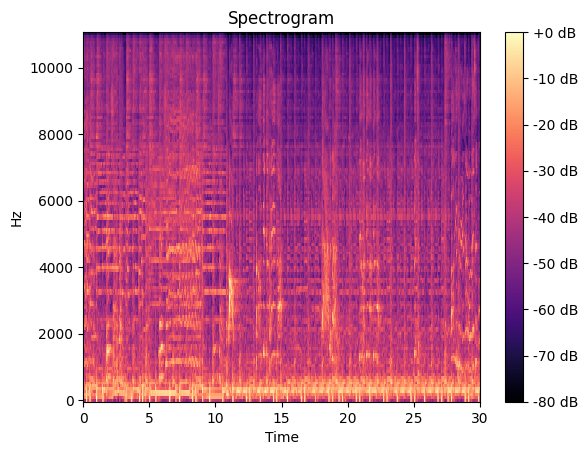

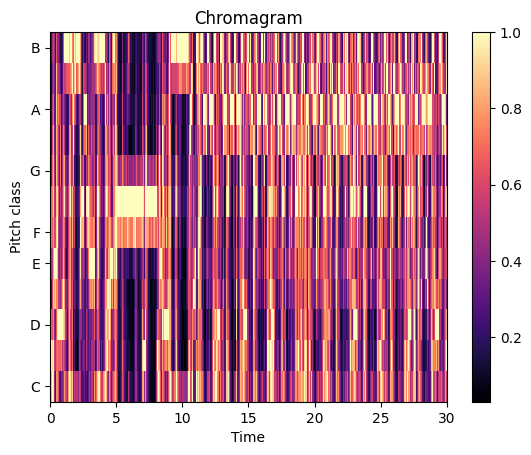

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:1]:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# clone the respective repo
# make sure you have the Internet option enabled under Session options
!git clone https://github.com/slp-ntua/patrec-labs.git

# add path to system
import sys
sys.path.append('/kaggle/working/patrec-labs/lab3')

!ls

# install requirements
!pip install -r patrec-labs/lab3/requirements.txt

# This is a fused spectrogram + chromagram. The shape is (mel + chroma frequencies, timesteps)
spec = np.load('/kaggle/input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train/80238.fused.full.npy')
print(spec.shape)  # (frequencies x time steps)

# To decompose into the mel spectrogram and chromagram you can run:
mel, chroma = spec[:128], spec[128:]
print(mel.shape, chroma.shape)

# Plot the spectrogram and the chromagram

import librosa.display
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
img = librosa.display.specshow(mel, x_axis='time', y_axis='linear', ax=ax)
ax.set(title='Spectrogram')
fig.colorbar(img, ax=ax, format="%+2.f dB")


fig, ax = plt.subplots()
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax)
ax.set(title='Chromagram')
fig.colorbar(img, ax=ax)

### **Step 0 - Getting started with Kaggle kernels**

---

This cell lists the contents of the lab dataset root folder inside Kaggle’s `../input` directory.

The code:

1. Imports the standard `os` module.
2. Sets:

   ```python
   data_root = "../input/patreco3-multitask-affective-music/data/"
   ```

3. Calls:

   ```python
   print(os.listdir(data_root))
   ```

   which prints all entries (files and subdirectories) contained in `data_root`.

By running this cell, we verify that:

* The dataset **`geoparslp/patreco3-multitask-affective-music`** is correctly attached to the notebook.
* We can see the internal structure of the `data/` folder (e.g., subfolders with spectrograms, beat-synced spectrograms, affective labels, etc.).


In [3]:
import os  # standard library for file system operations

# List the contents of the lab dataset root folder
data_root = "../input/patreco3-multitask-affective-music/data/"
print(os.listdir(data_root))


['multitask_dataset_beat', 'fma_genre_spectrograms', 'fma_genre_spectrograms_beat', 'multitask_dataset']


### **Pre-Step 1**

---

Helper code that finds 2 tracks that exist in both directories: for steps 1 `fma_genre_spectograms/` and for step 2 `fma_genre_spectograms_beat/`. This will allow direct comparisons.

In [4]:
import os
import random

# Roots for original and beat-synced spectrograms
orig_root = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train"
beat_root = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/train"
labels_path = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train_labels.txt"

# --- 1) Map track_id -> filename in each dataset ---

orig_files = [f for f in os.listdir(orig_root) if f.endswith(".npy")]
beat_files = [f for f in os.listdir(beat_root) if f.endswith(".npy")]

orig_id_to_file = {}
for fname in orig_files:
    track_id = fname.split(".")[0]    # e.g. "11268" from "11268.fused.full.npy"
    orig_id_to_file[track_id] = fname

beat_id_to_file = {}
for fname in beat_files:
    track_id = fname.split(".")[0]    # e.g. "11268" from "11268.beatsync.fused.npy"
    beat_id_to_file[track_id] = fname

# IDs that exist in BOTH datasets
common_ids = sorted(set(orig_id_to_file) & set(beat_id_to_file))
print(f"Number of common track IDs: {len(common_ids)}")

# --- 2) Map track_id -> label using train_labels.txt ---

id_to_label = {}

with open(labels_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        raw_name = parts[0]               # e.g. "11268.fused.full.npy.gz"
        label = " ".join(parts[1:])       # handle labels with spaces
        track_id = raw_name.split(".")[0] # "11268"
        id_to_label[track_id] = label

# --- 3) Group common IDs by label and pick 2 tracks with different labels ---

by_label = {}  # label -> list of track_ids that are in both datasets

for tid in common_ids:
    if tid in id_to_label:
        lab = id_to_label[tid]
        by_label.setdefault(lab, []).append(tid)

labels = [lab for lab, tids in by_label.items() if len(tids) > 0]
print(f"Number of labels with at least one common track: {len(labels)}")

if len(labels) < 2:
    raise RuntimeError("Not enough distinct labels among common tracks.")

random.seed(0)

lab1, lab2 = random.sample(labels, 2)
tid1 = random.choice(by_label[lab1])
tid2 = random.choice(by_label[lab2])

print("\nChosen tracks that exist in BOTH datasets (original + beat-synced):")
print(f"  Track ID: {tid1}")
print(f"    Label:          {lab1}")
print(f"    Original file:  {orig_id_to_file[tid1]}")
print(f"    Beat-synced:    {beat_id_to_file[tid1]}")

print(f"\n  Track ID: {tid2}")
print(f"    Label:          {lab2}")
print(f"    Original file:  {orig_id_to_file[tid2]}")
print(f"    Beat-synced:    {beat_id_to_file[tid2]}")


Number of common track IDs: 3069
Number of labels with at least one common track: 20

Chosen tracks that exist in BOTH datasets (original + beat-synced):
  Track ID: 11273
    Label:          Trip-Hop
    Original file:  11273.fused.full.npy
    Beat-synced:    11273.fused.full.npy

  Track ID: 29459
    Label:          Psych-Folk
    Original file:  29459.fused.full.npy
    Beat-synced:    29459.fused.full.npy


### **Step 1: Familiarization with spectrograms on the mel scale**

---

In this step, we visualize the mel spectrograms of **two specific tracks** from the FMA genre dataset that we know exist in both the original and beat-synced spectrogram collections:

- Track ID `11273` — label: **Trip-Hop**  
- Track ID `29459` — label: **Psych-Folk**

The code does the following:

1. Scans the folder `fma_genre_spectrograms/train` and builds a mapping from numeric track ID (e.g., `"11273"`) to the actual fused spectrogram filename (e.g., `"11273.fused.full.npy"`).  
2. Parses `train_labels.txt` and builds a mapping from track ID to its genre label, using only tracks that also have a corresponding `.npy` file on disk.  
3. Explicitly selects the two track IDs `11273` (Trip-Hop) and `29459` (Psych-Folk), retrieves their filenames and labels, and prints:
   - the track ID,
   - the `.npy` filename,
   - the genre label.
4. Loads each fused spectrogram with `numpy.load`, keeps only the **mel spectrogram** by slicing the first 128 rows:
   ```python
   mel = spec[:128, :]
   ```
   and prints the resulting shapes:

   ```
   11273.fused.full.npy (Trip-Hop): (128, 1291)
   29459.fused.full.npy (Psych-Folk): (128, 1293)
   ```

   where 128 is the number of mel-frequency bins and 1291/1293 the number of time frames.

5. Plots the two mel spectrograms side by side with:

   ```python
   librosa.display.specshow(mel, x_axis="time", y_axis="mel")
   ```

   using time on the horizontal axis, mel-frequency bins on the vertical axis, and color to encode the magnitude.

Visually, the Trip-Hop track exhibits strong low-frequency energy with repeated vertical structures linked to drum hits and bass events, while the Psych-Folk track shows a richer mid-frequency texture with more horizontal components that correspond to sustained harmonic content (guitars, vocals, etc.). These plots give an intuitive first view of how different genres distribute their energy over time and frequency, and they will be reused in Step 2 to compare the original mel spectrograms with their beat-synced counterparts for the same audio excerpts.



Selected examples (exist in BOTH original and beat-synced datasets):
  Track ID 11273: file 11273.fused.full.npy, label Trip-Hop
  Track ID 29459: file 29459.fused.full.npy, label Psych-Folk
Mel spectrogram shapes: (128, 1291) (128, 1293)


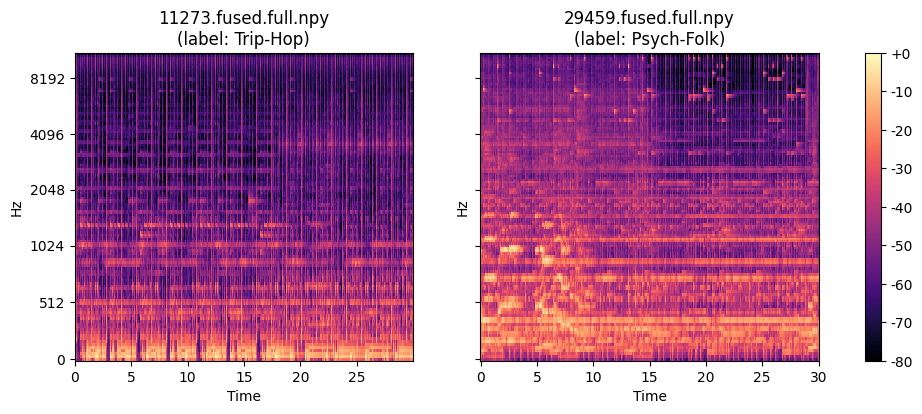

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display  # for spectrogram visualization

# Paths for labels and spectrograms
labels_path = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train_labels.txt"
spec_root   = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/train"

# -------------------------------------------------
# 1) Build a mapping: track ID -> actual .npy file
# -------------------------------------------------
spec_files = [f for f in os.listdir(spec_root) if f.endswith(".npy")]

id_to_file = {}  # e.g. "11273" -> "11273.fused.full.npy"
for fname in spec_files:
    track_id = fname.split(".")[0]   # "11273" from "11273.fused.full.npy"
    id_to_file[track_id] = fname

# -------------------------------------------------
# 2) Build a mapping: track ID -> label (from train_labels.txt)
# -------------------------------------------------
id_to_label = {}

with open(labels_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()
        raw_name = parts[0]                # e.g. "11273.fused.full.npy.gz"
        label    = " ".join(parts[1:])     # label may contain spaces

        track_id = raw_name.split(".")[0]  # "11273"
        if track_id in id_to_file:
            id_to_label[track_id] = label

# -------------------------------------------------
# 3) Explicitly choose the two common track IDs
#    (they exist in BOTH original and beat-synced datasets)
# -------------------------------------------------
tid1 = "11273"   # Trip-Hop
tid2 = "29459"   # Psych-Folk

if tid1 not in id_to_file or tid1 not in id_to_label:
    raise RuntimeError(f"Track ID {tid1} not found in files/labels.")
if tid2 not in id_to_file or tid2 not in id_to_label:
    raise RuntimeError(f"Track ID {tid2} not found in files/labels.")

f1, lab1 = id_to_file[tid1], id_to_label[tid1]
f2, lab2 = id_to_file[tid2], id_to_label[tid2]

print("Selected examples (exist in BOTH original and beat-synced datasets):")
print(f"  Track ID {tid1}: file {f1}, label {lab1}")
print(f"  Track ID {tid2}: file {f2}, label {lab2}")

# -------------------------------------------------
# 4) Load fused spectrograms and extract mel parts
# -------------------------------------------------
def load_mel_from_fused(filename: str) -> np.ndarray:
    """
    Load fused (mel + chroma) spectrogram for a file and return only
    the mel spectrogram (first 128 frequency bins).
    """
    fused_path = os.path.join(spec_root, filename)
    spec = np.load(fused_path)       # shape: (mel_bins + chroma_bins, time_steps)
    mel  = spec[:128, :]             # first 128 rows = mel spectrogram
    return mel

mel1 = load_mel_from_fused(f1)
mel2 = load_mel_from_fused(f2)

print("Mel spectrogram shapes:", mel1.shape, mel2.shape)

# -------------------------------------------------
# 5) Visualize the two mel spectrograms
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

img1 = librosa.display.specshow(mel1, ax=axes[0], x_axis="time", y_axis="mel")
axes[0].set_title(f"{f1}\n(label: {lab1})")

img2 = librosa.display.specshow(mel2, ax=axes[1], x_axis="time", y_axis="mel")
axes[1].set_title(f"{f2}\n(label: {lab2})")

fig.colorbar(img1, ax=axes, format="%+2.0f")  # shared colorbar
plt.show()


### **Step 2: Synchronizing spectrograms to the beat of the music (beat-synced spectrograms)**

In this step, we revisit the **same two tracks** used in Step 1:

- `11273.fused.full.npy` — label: **Trip-Hop**  
- `29459.fused.full.npy` — label: **Psych-Folk**

and compare their original mel spectrograms to their **beat-synced** versions.

1. **Step 2(a) – Original mel spectrograms**

   We reuse the mel spectrograms computed in Step 1 and print their shapes:

   - Trip-Hop (`11273`): `(128, 1291)`  
   - Psych-Folk (`29459`): `(128, 1293)`

   Each track is therefore represented as a sequence of around **1300 time steps** (1291 or 1293), with **128 mel-frequency bins** at each step. For an LSTM, this means long input sequences, higher computational cost per update, more memory usage, and a greater risk of vanishing/exploding gradients, especially if we stack multiple recurrent layers.

2. **Step 2(b) – Beat-synced mel spectrograms for the same songs**

   We move to the folder  
   `fma_genre_spectrograms_beat/train`, which contains beat-synced fused spectrograms.  
   For each track ID (11273, 29459), we:

   - Search for the corresponding beat-synced file whose name starts with that ID (preferring filenames that contain `beatsync` when multiple candidates exist).  
   - Load the fused array with `numpy.load` and keep only the first 128 rows to obtain the beat-synced mel spectrogram.  
   - Remove any trailing columns that are (almost) zero so that we plot only the **valid beat frames** (no zero padding).

   The resulting shapes are:

   - Trip-Hop (`11273`): full `(128, 45)`, cropped `(128, 45)` → **45 beat frames**  
   - Psych-Folk (`29459`): full `(128, 69)`, cropped `(128, 69)` → **69 beat frames**

   Compared to ~1300 short-time frames, the beat-synced representations are **much shorter** (roughly 20–30× fewer time steps), yet each frame now corresponds to a musically meaningful beat position.

3. **Visualization**

   We plot the two cropped beat-synced mel spectrograms side by side using:

   ```python
   librosa.display.specshow(mel_beat, x_axis="frames", y_axis="mel")
   ```

   with the beat index on the x-axis and mel-frequency bins on the y-axis.  
   The overall spectral patterns are similar to the original spectrograms in Step 1, but compressed in time: the Trip-Hop track still shows strong low-frequency energy and repetitive vertical structures aligned with the beats, while the Psych-Folk track preserves its richer mid-frequency texture and sustained harmonic components.

For LSTM training, these beat-synced spectrograms are far more convenient: they keep the essential spectral–rhythmic structure of each song while greatly reducing sequence length, leading to faster training, less memory usage, and more stable gradient propagation.


Original mel spectrogram 1:
  file   = 11273.fused.full.npy
  label  = Trip-Hop
  shape  = (128, 1291)  (mel_bins = 128, time_steps = 1291)

Original mel spectrogram 2:
  file   = 29459.fused.full.npy
  label  = Psych-Folk
  shape  = (128, 1293)  (mel_bins = 128, time_steps = 1293)

Beat-synced mel spectrograms for the SAME tracks:
  Example 1:
    file             = 11273.fused.full.npy
    label            = Trip-Hop
    full shape       = (128, 45)  (mel_bins = 128, time_steps = 45)
    cropped shape    = (128, 45)  (mel_bins = 128, time_steps = 45)
    valid time steps ≈ 45

  Example 2:
    file             = 29459.fused.full.npy
    label            = Psych-Folk
    full shape       = (128, 69)  (mel_bins = 128, time_steps = 69)
    cropped shape    = (128, 69)  (mel_bins = 128, time_steps = 69)
    valid time steps ≈ 69



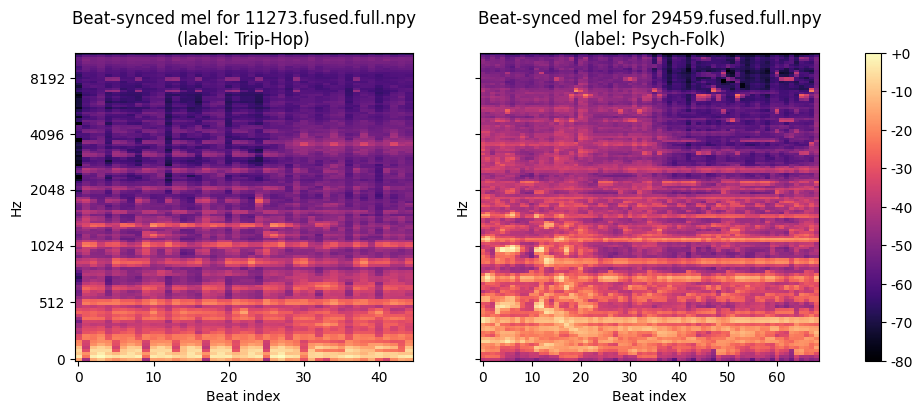

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# -------------------------------------------------
# 2(a) Original mel spectrograms (from Step 1)
# -------------------------------------------------

for idx, (fname, label, mel) in enumerate(
    [(f1, lab1, mel1), (f2, lab2, mel2)], start=1
):
    n_mel, T = mel.shape
    print(f"Original mel spectrogram {idx}:")
    print(f"  file   = {fname}")
    print(f"  label  = {label}")
    print(f"  shape  = {mel.shape}  (mel_bins = {n_mel}, time_steps = {T})")
    print()

# -------------------------------------------------
# 2(b) Beat-synced mel spectrograms for the SAME tracks
# -------------------------------------------------

beat_root = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/train"

# Helper: find the beat-synced file corresponding to a given track_id
beat_files = [f for f in os.listdir(beat_root) if f.endswith(".npy")]

def find_beat_file(track_id: str) -> str:
    """
    Given a numeric track ID (e.g. '11273'), find the corresponding
    beat-synced file in beat_root. We look for files whose name starts
    with this ID before the first dot, and prefer those containing
    'beatsync' if multiple candidates exist.
    """
    candidates = [f for f in beat_files if f.split(".")[0] == track_id]
    if not candidates:
        raise FileNotFoundError(f"No beat-synced file found for ID {track_id}")
    # Prefer filenames that explicitly contain 'beatsync'
    candidates.sort(key=lambda name: ("beatsync" not in name, name))
    return candidates[0]

def load_beat_mel_for_fused_filename(fused_fname: str) -> np.ndarray:
    """
    From the original fused filename (e.g. '11273.fused.full.npy'),
    extract the track ID and load the corresponding beat-synced
    fused spectrogram. Return only the mel part (first 128 rows).
    """
    track_id = fused_fname.split(".")[0]           # '11273'
    beat_fname = find_beat_file(track_id)
    beat_path = os.path.join(beat_root, beat_fname)
    spec_beat = np.load(beat_path)                # (mel+chroma, time_steps)
    mel_beat = spec_beat[:128, :]                 # keep only mel part
    return mel_beat

def crop_valid_columns(mel: np.ndarray, eps: float = 1e-8):
    """
    Remove trailing columns that are (almost) all zeros (padding).
    This approximates the true beat-synced length so the plot
    does not show a large zero-padded region.
    """
    energy = np.abs(mel).sum(axis=0)              # energy per time frame
    valid_mask = energy > eps
    if not np.any(valid_mask):
        return mel, mel.shape[1]
    last_valid = np.where(valid_mask)[0].max()
    cropped = mel[:, : last_valid + 1]
    return cropped, last_valid + 1

# Load beat-synced mel spectrograms for the same two tracks
mel_beat1_full = load_beat_mel_for_fused_filename(f1)
mel_beat2_full = load_beat_mel_for_fused_filename(f2)

mel_beat1, T1 = crop_valid_columns(mel_beat1_full)
mel_beat2, T2 = crop_valid_columns(mel_beat2_full)

print("Beat-synced mel spectrograms for the SAME tracks:")
for idx, (fname, label, mel_full, mel_crop, T_crop) in enumerate(
    [
        (f1, lab1, mel_beat1_full, mel_beat1, T1),
        (f2, lab2, mel_beat2_full, mel_beat2, T2),
    ],
    start=1,
):
    n_mel_f, T_f = mel_full.shape
    n_mel_c, T_c = mel_crop.shape
    print(f"  Example {idx}:")
    print(f"    file             = {fname}")
    print(f"    label            = {label}")
    print(f"    full shape       = {mel_full.shape}  (mel_bins = {n_mel_f}, time_steps = {T_f})")
    print(f"    cropped shape    = {mel_crop.shape}  (mel_bins = {n_mel_c}, time_steps = {T_c})")
    print(f"    valid time steps ≈ {T_crop}")
    print()

# -------------------------------------------------
# Plot the beat-synced mel spectrograms (cropped)
# -------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

img1 = librosa.display.specshow(mel_beat1, ax=axes[0], x_axis="frames", y_axis="mel")
axes[0].set_title(f"Beat-synced mel for {f1}\n(label: {lab1})")
axes[0].set_xlabel("Beat index")

img2 = librosa.display.specshow(mel_beat2, ax=axes[1], x_axis="frames", y_axis="mel")
axes[1].set_title(f"Beat-synced mel for {f2}\n(label: {lab2})")
axes[1].set_xlabel("Beat index")

fig.colorbar(img1, ax=axes, format="%+2.0f")
plt.show()


### **Step 3: Familiarization with chromatograms**

---

In this step, we repeat the analysis of Steps 1–2, but using **chromagrams** instead of mel spectrograms. A chromagram compresses the spectrum into 12 pitch classes `{C, C#, D, …, B}` per time step, emphasizing harmonic and melodic structure while being relatively robust to changes in timbre and instrumentation.

1. **Original chromagrams (repeating Step 1 for chroma)**  
   From the original fused spectrograms in `fma_genre_spectrograms/train`, we extract the chromagram by taking the rows `128:` of the fused array, which correspond to the 12 pitch-class bins. For the same two tracks as before, we obtain:

   - Trip-Hop (`11273.fused.full.npy`): chromagram shape **(12, 1291)**  
   - Psych-Folk (`29459.fused.full.npy`): chromagram shape **(12, 1293)**  

   So each song is represented as a sequence of ≈1300 time frames with 12 pitch-class features each.  
   The plots show how pitch classes evolve over time:
   - For the **Trip-Hop** track, the chromagram is dominated by a few pitch classes (e.g., around A and G), with repeated vertical patterns that reflect the repetitive harmonic loop typical of the genre.  
   - For the **Psych-Folk** track, the chroma energy is distributed over more pitch classes with smoother changes, indicating richer chord progressions and more melodic variation.

2. **Beat-synced chromagrams (repeating Step 2 for chroma)**  
   We then move to the beat-synced fused spectrograms in `fma_genre_spectrograms_beat/train`. For each track ID (11273, 29459), we:
   - Find the corresponding beat-synced file.  
   - Load it and again extract only the chromagram part (rows `128:`).  
   - Remove any trailing zero-padded frames using an energy-based threshold, keeping only valid beat positions.

   The resulting shapes are:

   - Trip-Hop (`11273`): full `(12, 45)`, cropped `(12, 45)` → **45 beat frames**  
   - Psych-Folk (`29459`): full `(12, 69)`, cropped `(12, 69)` → **69 beat frames**  

   This mirrors the reduction we saw with the mel spectrograms: we go from ~1290 short-time frames down to a few dozen beat-synchronous chroma frames, while still capturing the main harmonic structure of each song.

3. **Visualization and interpretation**  
   We plot the beat-synced chromagrams with:
   ```python
   librosa.display.specshow(chroma_beat, x_axis="frames", y_axis="chroma")
   ```
   using the beat index on the x-axis and pitch class on the y-axis.  
   The Trip-Hop track shows strong, recurring activation of a small subset of pitch classes at many beats, reflecting a stable tonal center and repetitive harmony. The Psych-Folk track, by contrast, distributes energy across more pitch classes and exhibits longer horizontal bands, corresponding to sustained chords and modulations.

Overall, Step 3 confirms that chromagrams provide a compact representation of the harmonic content, and their beat-synced versions yield short, musically meaningful sequences that are particularly well suited as input to sequence models such as LSTMs.


Original chromagrams:
  Track 1:
    file   = 11273.fused.full.npy
    label  = Trip-Hop
    shape  = (12, 1291)  (chroma_bins = 12, time_steps = 1291)

  Track 2:
    file   = 29459.fused.full.npy
    label  = Psych-Folk
    shape  = (12, 1293)  (chroma_bins = 12, time_steps = 1293)



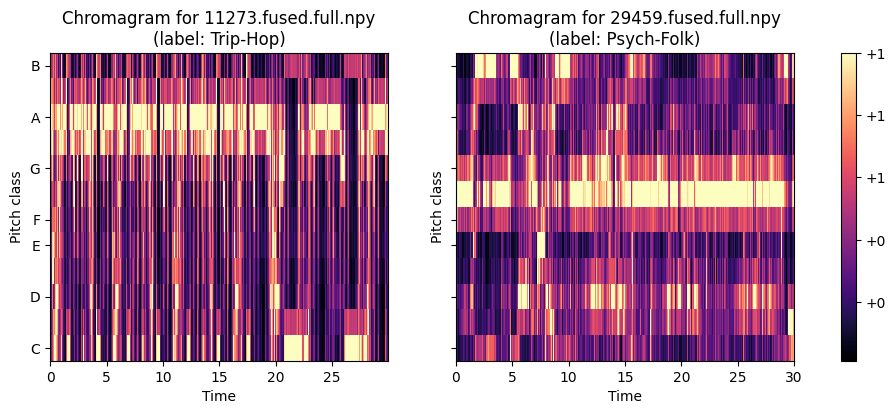

Beat-synced chromagrams for the SAME tracks:
  Track 1:
    file             = 11273.fused.full.npy
    label            = Trip-Hop
    full shape       = (12, 45)  (chroma_bins = 12, time_steps = 45)
    cropped shape    = (12, 45)  (chroma_bins = 12, time_steps = 45)
    valid time steps ≈ 45

  Track 2:
    file             = 29459.fused.full.npy
    label            = Psych-Folk
    full shape       = (12, 69)  (chroma_bins = 12, time_steps = 69)
    cropped shape    = (12, 69)  (chroma_bins = 12, time_steps = 69)
    valid time steps ≈ 69



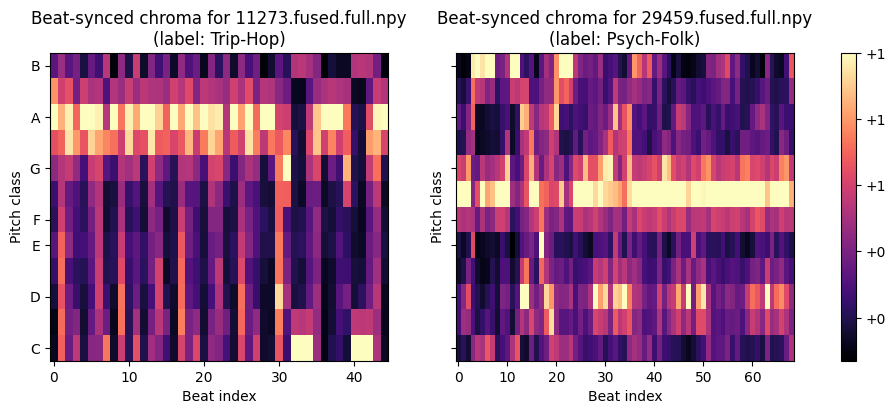

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# -------------------------------------------------
# 3(a, b, c) Chromagrams from original fused spectrograms (Step 1 repeated)
# -------------------------------------------------

def load_chroma_from_fused(filename: str) -> np.ndarray:
    """Load fused (mel + chroma) spectrogram and return only the chromagram."""
    fused_path = os.path.join(spec_root, filename)
    spec = np.load(fused_path)          # (mel_bins + chroma_bins, time_steps)
    chroma = spec[128:, :]              # rows 128: → chroma (12 x T)
    return chroma

chroma1 = load_chroma_from_fused(f1)
chroma2 = load_chroma_from_fused(f2)

print("Original chromagrams:")
for idx, (fname, label, chroma) in enumerate(
    [(f1, lab1, chroma1), (f2, lab2, chroma2)], start=1
):
    n_chroma, T = chroma.shape
    print(f"  Track {idx}:")
    print(f"    file   = {fname}")
    print(f"    label  = {label}")
    print(f"    shape  = {chroma.shape}  (chroma_bins = {n_chroma}, time_steps = {T})")
    print()

# Visualize original chromagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

img1 = librosa.display.specshow(
    chroma1, ax=axes[0], x_axis="time", y_axis="chroma"
)
axes[0].set_title(f"Chromagram for {f1}\n(label: {lab1})")

img2 = librosa.display.specshow(
    chroma2, ax=axes[1], x_axis="time", y_axis="chroma"
)
axes[1].set_title(f"Chromagram for {f2}\n(label: {lab2})")

fig.colorbar(img1, ax=axes, format="%+2.0f")
plt.show()

# -------------------------------------------------
# 3 – Beat-synced chromagrams (Steps 1 & 2 repeated for chroma)
# -------------------------------------------------

beat_files = [f for f in os.listdir(beat_root) if f.endswith(".npy")]

def find_beat_file(track_id: str) -> str:
    """Find beat-synced file in beat_root whose name starts with the given ID."""
    candidates = [f for f in beat_files if f.split(".")[0] == track_id]
    if not candidates:
        raise FileNotFoundError(f"No beat-synced file found for ID {track_id}")
    candidates.sort(key=lambda name: ("beatsync" not in name, name))
    return candidates[0]

def load_beat_chroma_for_fused_filename(fused_fname: str) -> np.ndarray:
    """Load beat-synced fused spectrogram and return only the chromagram part."""
    track_id = fused_fname.split(".")[0]
    beat_fname = find_beat_file(track_id)
    beat_path = os.path.join(beat_root, beat_fname)
    spec_beat = np.load(beat_path)      # (mel + chroma, time_steps)
    chroma_beat = spec_beat[128:, :]    # chroma rows (12 x T)
    return chroma_beat

def crop_valid_columns(feat: np.ndarray, eps: float = 1e-8):
    """Remove trailing columns with (almost) zero energy (padding)."""
    energy = np.abs(feat).sum(axis=0)
    valid_mask = energy > eps
    if not np.any(valid_mask):
        return feat, feat.shape[1]
    last_valid = np.where(valid_mask)[0].max()
    cropped = feat[:, : last_valid + 1]
    return cropped, last_valid + 1

chroma_beat1_full = load_beat_chroma_for_fused_filename(f1)
chroma_beat2_full = load_beat_chroma_for_fused_filename(f2)

chroma_beat1, T1 = crop_valid_columns(chroma_beat1_full)
chroma_beat2, T2 = crop_valid_columns(chroma_beat2_full)

print("Beat-synced chromagrams for the SAME tracks:")
for idx, (fname, label, full_c, crop_c, T_crop) in enumerate(
    [
        (f1, lab1, chroma_beat1_full, chroma_beat1, T1),
        (f2, lab2, chroma_beat2_full, chroma_beat2, T2),
    ],
    start=1,
):
    n_full, T_full = full_c.shape
    n_crop, T_c = crop_c.shape
    print(f"  Track {idx}:")
    print(f"    file             = {fname}")
    print(f"    label            = {label}")
    print(f"    full shape       = {full_c.shape}  (chroma_bins = {n_full}, time_steps = {T_full})")
    print(f"    cropped shape    = {crop_c.shape}  (chroma_bins = {n_crop}, time_steps = {T_c})")
    print(f"    valid time steps ≈ {T_crop}")
    print()

# Visualize beat-synced chromagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

img1 = librosa.display.specshow(
    chroma_beat1, ax=axes[0], x_axis="frames", y_axis="chroma"
)
axes[0].set_title(f"Beat-synced chroma for {f1}\n(label: {lab1})")
axes[0].set_xlabel("Beat index")

img2 = librosa.display.specshow(
    chroma_beat2, ax=axes[1], x_axis="frames", y_axis="chroma"
)
axes[1].set_title(f"Beat-synced chroma for {f2}\n(label: {lab2})")
axes[1].set_xlabel("Beat index")

fig.colorbar(img1, ax=axes, format="%+2.0f")
plt.show()


### **Step 4: Data loading and analysis**

---

In this step, we use the helper code from the lab to inspect the **PyTorch `SpectrogramDataset`**, study how the classes are merged, and visualize the class distributions before and after this processing.

1. **Inspecting a single dataset sample (Step 4a)**  
   We create a `SpectrogramDataset` over the original fused spectrograms:
   ```python
   train_dataset = SpectrogramDataset(
       os.path.join(PARENT_DATA_DIR, "fma_genre_spectrograms"),
       class_mapping=CLASS_MAPPING,
       train=True,
   )
   ```
   and print `train_dataset[10]`.  
   The dataset returns a tuple:
   ```python
   (spectrogram, label, original_length)
   ```
   where:

   - **spectrogram** is a 2D tensor/array of shape `(T, F)` containing log-magnitude time–frequency values  
     (here we see values between about −80 dB and 0 dB).  
   - **label** is an integer class index (e.g. `0`).  
   - **original_length** is the true sequence length before any padding or truncation  
     (e.g., `1291` frames).

   For the inspected item, we obtained:

   - printed tuple: `(..., 0, 1291)`  
   - Input: `(1293, 128)` → meaning the stored spectrogram has **1293 time frames** and **128 frequency bins**  
   - Label: `0`  
   - Original length: `1291` → the last few frames are padding

   This confirms that the dataset is responsible for both loading the `.npy` spectrograms and for tracking the valid sequence length for each example.

2. **Class merging / filtering and histograms (Step 4b–c)**  
   We then construct two datasets:

   - **train_dataset_all**  
     ```python
     SpectrogramDataset(..., class_mapping=None, train=True)
     ```  
     which keeps **all original classes** from the label file  
     (20 genres in our case).

   - **train_dataset**  
     ```python
     SpectrogramDataset(..., class_mapping=CLASS_MAPPING, train=True)
     ```  
     which applies `CLASS_MAPPING` from the helper code to **merge similar genres into broader groups**  
     and **remove classes with very few samples**.

   Using the provided `plot_class_histogram` helper, we plot:

   - **Histogram of classes (all classes)**:  
     20 bars (class IDs 0–19), each with roughly 250–320 examples.  
     This is the raw distribution directly from the dataset.

   - **Histogram of classes (merged / filtered)**:  
     10 bars (class IDs 0–9), with more balanced and higher counts per class  
     (e.g., one merged class exceeds 400 examples, while the smallest still has well over 100).

   These plots show how the mapping merges similar genres into fewer, better-populated classes and drops under-represented ones.  
   This simplifies the task and avoids poorly sampled classes.

3. **Data loader and input shapes for mel features**

   Finally, we create another `SpectrogramDataset` focusing on mel features:

   ```python
   train_dataset = SpectrogramDataset(
       os.path.join(PARENT_DATA_DIR, "fma_genre_spectrograms"),
       class_mapping=CLASS_MAPPING,
       train=True,
       feat_type="mel",
       max_length=MAX_LENGTH,  # here MAX_LENGTH = 150
   )
   ```

   and wrap it with `torch_train_val_split` to obtain a training and validation `DataLoader`.

   Inspecting the first batch:

   ```python
   x_b1, y_b1, lengths_b1 = next(iter(train_loader))
   print(x_b1[0].shape)  # -> torch.Size([150, 128])
   ```

   This means that **each input sequence fed to the model has been padded or truncated to 150 time steps**,  
   with **128 mel-frequency features per step**.  
   This standardized shape `(T = 150, F = 128)` is exactly what we need later for LSTM-based classifiers, because it:

   - avoids variable-length tensors inside the batch  
   - preserves the original sequence length via `lengths_b1`  
   - ensures efficient batching and stable training  


(array([[-52.26681477, -52.71678237, -52.83256794, ..., -80.        ,
        -80.        , -80.        ],
       [-45.12944043, -49.20641678, -51.77639735, ..., -80.        ,
        -80.        , -80.        ],
       [-44.2435711 , -42.88079978, -46.60278858, ..., -80.        ,
        -80.        , -80.        ],
       ...,
       [-38.86648128, -42.70998466, -46.1181    , ..., -58.58672545,
        -61.70087117, -63.41518897],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]]), 0, 1291)
Input: (1293, 128)
Label: 0
Original length: 1291
torch.Size([150, 128])


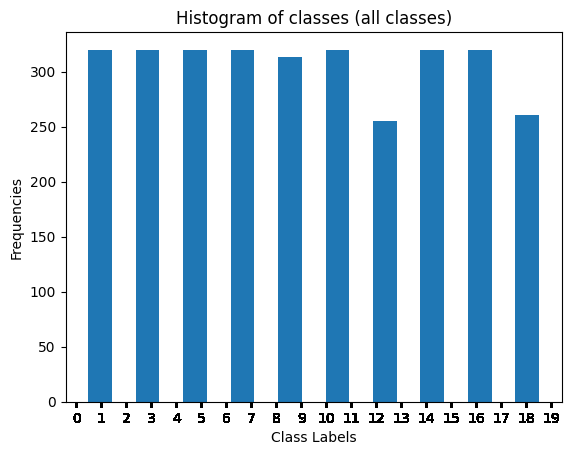

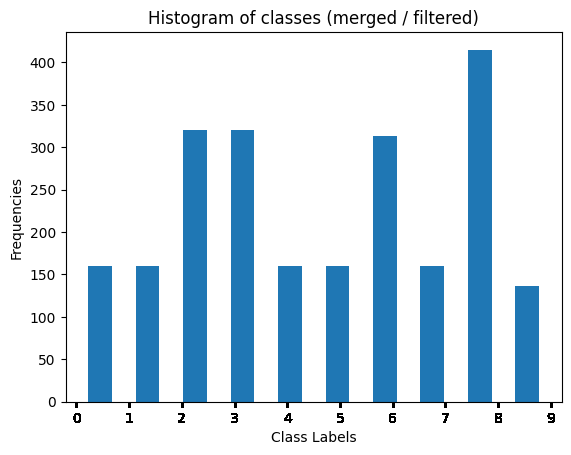

In [8]:
import os
import matplotlib.pyplot as plt

from dataset import CLASS_MAPPING, SpectrogramDataset, torch_train_val_split

PARENT_DATA_DIR = '../input/patreco3-multitask-affective-music/data/'

# -------------------------------------------------
# Step 4(a) — Inspect SpectrogramDataset sample
# -------------------------------------------------
train_dataset = SpectrogramDataset(
    os.path.join(PARENT_DATA_DIR, 'fma_genre_spectrograms'),
    class_mapping=CLASS_MAPPING,
    train=True
)

print(train_dataset[10])
print(f"Input: {train_dataset[10][0].shape}")
print(f"Label: {train_dataset[10][1]}")
print(f"Original length: {train_dataset[10][2]}")

# -------------------------------------------------
# Step 4(b,c) — Histograms before/after class merging
# -------------------------------------------------
def plot_class_histogram(dataset, title):
    plt.figure()
    plt.hist(dataset.labels, rwidth=0.5, align='mid')
    plt.xticks(dataset.labels, dataset.labels.astype(str))
    plt.title(title)
    plt.xlabel('Class Labels')
    plt.ylabel('Frequencies')

# Before merging / filtering (all original classes)
train_dataset_all = SpectrogramDataset(
    os.path.join(PARENT_DATA_DIR, 'fma_genre_spectrograms'),
    class_mapping=None,
    train=True
)
plot_class_histogram(train_dataset_all, title='Histogram of classes (all classes)')

# After merging / filtering (uses CLASS_MAPPING)
plot_class_histogram(train_dataset, title='Histogram of classes (merged / filtered)')

# -------------------------------------------------
# Data loaders for mel features (as in helper code)
# -------------------------------------------------
BATCH_SIZE = 8
MAX_LENGTH = 150
DEVICE = 'cuda'

train_dataset = SpectrogramDataset(
    os.path.join(PARENT_DATA_DIR, 'fma_genre_spectrograms'),
    class_mapping=CLASS_MAPPING,
    train=True,
    feat_type='mel',
    max_length=MAX_LENGTH
)

train_loader, val_loader = torch_train_val_split(
    train_dataset, BATCH_SIZE, BATCH_SIZE
)

# Get the 1st batch values of the data loader
x_b1, y_b1, lengths_b1 = next(iter(train_loader))

# Print the shape of the 1st item of the 1st batch
input_shape = x_b1[0].shape
print(input_shape)


### **Step 5: Music genre recognition with LSTM**

---

We split the LSTM code into three parts:

1. **Definitions cell (5.1)**  
   - Imports the professor’s `LSTMBackbone` (from `lstm.py`) and the `SpectrogramDataset` and helpers from `dataset.py`.  
   - Sets global hyperparameters (GPU device, batch size, max sequence length, learning rate, number of epochs).  
   - Implements `make_loaders`, which builds a `SpectrogramDataset` for a chosen feature type (`mel`, `chroma`, `fused`) and returns train/validation DataLoaders.  
   - Includes the professor’s `overfit_with_a_couple_of_batches` routine, which overfits on a single batch to verify that gradients flow correctly (Step 5b).  
   - Defines the `Classifier` wrapper around `LSTMBackbone`, the `EarlyStopper` logic, one-epoch training/validation loops, and a main `train()` function with a boolean flag `overfit_batch`.  
   - Provides a high-level `run_experiment()` helper that runs the whole pipeline for a given feature configuration and saves the best model.

2. **Overfit runs (5.2)**  
   - Calls `run_experiment(..., overfit_batch=True)` for four feature configurations:
     - Mel spectrograms (original dataset)  
     - Beat-synced mel spectrograms  
     - Chromagrams  
     - Fused (mel + chroma) spectrograms  
   - In this mode, `train()` delegates to `overfit_with_a_couple_of_batches`, which trains the model on only one batch for many epochs.  
   - The goal is to observe the training loss drop close to zero, confirming that the model, loss, and optimizer are implemented correctly and that backpropagation works as expected.

3. **Normal training runs (5.3)**  
   - Calls `run_experiment(..., overfit_batch=False)` for the same four feature types.  
   - Each call:
     - Builds train/validation loaders (optionally on a `Subset` of the data for faster tuning).  
     - Constructs an LSTM with input dimension equal to the feature size (mel bins, chroma bins, or fused channels), hidden size 128, 2 layers, bidirectional recurrence, and a final linear classifier.  
     - Trains with Adam optimizer on the training set, monitors loss on the validation set, and uses `EarlyStopper` to stop early and save the best checkpoint.  
   - These runs implement:
     - **Step 5(c):** LSTM on mel spectrograms.  
     - **Step 5(d):** LSTM on beat-synced mel spectrograms.  
     - **Step 5(e):** LSTM on chromagrams.  
     - **Step 5(ζ):** LSTM on concatenated (fused) mel + chroma features.

With this structure, we can first debug using the overfitting cell and then run full training experiments for all feature representations using exactly the same LSTM code and Dataset interface as in the professor’s template.


In [9]:
# ==========================
# Step 5.1 – LSTM definitions
# ==========================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Subset

from lstm import LSTMBackbone
from dataset import SpectrogramDataset, CLASS_MAPPING, torch_train_val_split

# --------------------------
# Global configuration
# --------------------------
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE   = 8
MAX_LENGTH   = 150          # time steps kept per sequence
NUM_CATEGORIES = len(CLASS_MAPPING)
LR           = 1e-4
EPOCHS       = 40

MEL_ROOT  = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/"
BEAT_ROOT = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms_beat/"

# --------------------------
# Build Dataset + DataLoaders
# --------------------------
def make_loaders(data_root,
                 feat_type,
                 max_length=MAX_LENGTH,
                 batch_size=BATCH_SIZE,
                 val_size=0.2,
                 subset_size=None):
    """
    Create SpectrogramDataset + train/val DataLoaders for a given feature type.
    Optionally restrict to a smaller subset of indices for faster debugging.
    """
    dataset = SpectrogramDataset(
        data_root,
        class_mapping=CLASS_MAPPING,
        train=True,
        feat_type=feat_type,
        max_length=max_length,
    )

    if subset_size is not None and subset_size < len(dataset):
        indices = list(range(subset_size))
        dataset = Subset(dataset, indices)

    train_loader, val_loader = torch_train_val_split(
        dataset, batch_size, batch_size, val_size=val_size
    )

    # Inspect one example to infer (T, D)
    x_b, y_b, lengths_b = next(iter(train_loader))
    input_shape = x_b[0].shape  # (time_steps, feature_dim)
    print(f"{feat_type} example shape (T, D):", input_shape)

    return train_loader, val_loader, input_shape

# --------------------------
# Overfit on a single batch
# --------------------------
def overfit_with_a_couple_of_batches(model, train_loader, optimizer, device):
    """
    Professor's debugging routine:
    overfit the model on one batch to check that gradients flow correctly.
    """
    print("Training in overfitting mode...")
    epochs = 400

    # take only the 1st batch
    x_b1, y_b1, lengths_b1 = next(iter(train_loader))
    model.train()
    for epoch in range(epochs):
        loss, logits = model(
            x_b1.float().to(device),
            y_b1.to(device),
            lengths_b1.to(device),
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch == 0 or (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}, Loss at training set: {loss.item()}")

# --------------------------
# Classifier wrapper
# --------------------------
class Classifier(nn.Module):
    """
    Thin wrapper around LSTMBackbone:
    backbone → feature vector → Linear layer → genre logits.
    """
    def __init__(self, num_classes, backbone, load_from_checkpoint=None):
        super(Classifier, self).__init__()
        self.backbone = backbone  # LSTMBackbone (or CNNBackbone in other labs)
        if load_from_checkpoint is not None:
            # Kept for compatibility with the professor's codebase
            self.backbone = load_backbone_from_checkpoint(
                self.backbone, load_from_checkpoint
            )
        self.is_lstm = isinstance(self.backbone, LSTMBackbone)
        self.output_layer = nn.Linear(self.backbone.feature_size, num_classes)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x, targets, lengths):
        # For LSTM we also pass lengths (for packing/masking)
        feats = self.backbone(x) if not self.is_lstm else self.backbone(x, lengths)
        logits = self.output_layer(feats)
        loss = self.criterion(logits, targets)
        return loss, logits

# --------------------------
# Early stopping + 1-epoch loops
# --------------------------
class EarlyStopper:
    def __init__(self, model, save_path, patience=1, min_delta=0):
        self.model = model
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            torch.save(self.model.state_dict(), self.save_path)
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

def train_one_epoch(model, train_loader, optimizer, device=DEVICE):
    model.train()
    total_loss = 0.0

    for x, y, lengths in train_loader:
        loss, logits = model(
            x.float().to(device),
            y.to(device),
            lengths.to(device),
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss

def validate_one_epoch(model, val_loader, device=DEVICE):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y, lengths in val_loader:
            loss, logits = model(
                x.float().to(device),
                y.to(device),
                lengths.to(device),
            )
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

# --------------------------
# Main train() with overfit flag
# --------------------------
def train(model, train_loader, val_loader, optimizer, epochs,
          save_path="checkpoint.pth", device="cuda", overfit_batch=False):
    """
    If overfit_batch == True:
        - run the small-batch overfitting routine only.
    Else:
        - run normal training with early stopping on validation loss.
    """
    if overfit_batch:
        overfit_with_a_couple_of_batches(model, train_loader, optimizer, device)
    else:
        print(f"Training started for model {save_path.replace('.pth', '')}...")
        early_stopper = EarlyStopper(model, save_path, patience=5)

        for epoch in range(epochs):
            train_loss = train_one_epoch(model, train_loader, optimizer, device=device)
            val_loss = validate_one_epoch(model, val_loader, device=device)

            if epoch == 0 or (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1}/{epochs}, "
                    f"Loss at training set: {train_loss:.4f}\n\t"
                    f"Loss at validation set: {val_loss:.4f}"
                )

            if early_stopper.early_stop(val_loss):
                print("Early Stopping was activated.")
                print(
                    f"Epoch {epoch+1}/{epochs}, "
                    f"Loss at training set: {train_loss:.4f}\n\t"
                    f"Loss at validation set: {val_loss:.4f}"
                )
                print("Training has been completed.\n")
                break

# --------------------------
# Run a complete LSTM experiment
# --------------------------
def run_experiment(feature_name,
                   data_root,
                   feat_type,
                   save_path,
                   max_length=MAX_LENGTH,
                   batch_size=BATCH_SIZE,
                   subset_size=None,
                   overfit_batch=False):
    """
    Helper that:
      1) Builds loaders for the chosen feature type (mel / chroma / fused).
      2) Constructs an LSTMBackbone and a Classifier.
      3) Trains the model with the train() function above.
    """
    print(f"\n=== LSTM training for {feature_name} ({feat_type}) ===")

    train_loader, val_loader, input_shape = make_loaders(
        data_root=data_root,
        feat_type=feat_type,
        max_length=max_length,
        batch_size=batch_size,
        val_size=0.2,
        subset_size=subset_size,
    )

    hidden_size = 128
    backbone = LSTMBackbone(
        input_shape[1],      # feature_dim
        rnn_size=hidden_size,
        num_layers=2,
        bidirectional=True,
    )
    model = Classifier(NUM_CATEGORIES, backbone).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train(
        model,
        train_loader,
        val_loader,
        optimizer,
        epochs=EPOCHS,
        save_path=save_path,
        device=DEVICE,
        overfit_batch=overfit_batch,
    )


In [12]:
# ===========================================
# Step 5.2 – Overfit mode on a few batches
#   (useful during development / debugging)
# ===========================================

# Optional: you can set subset_size to a small value (e.g. 256)
# to build the loaders faster during debugging.
SUBSET_FOR_OVERFIT = None  # or 256, 512, ...

run_experiment(
    feature_name="mel spectrograms (overfit)",
    data_root=MEL_ROOT,
    feat_type="mel",
    save_path="lstm_genre_mel_overfit.pth",
    subset_size=SUBSET_FOR_OVERFIT,
    overfit_batch=True,
)

run_experiment(
    feature_name="beat-synced mel spectrograms (overfit)",
    data_root=BEAT_ROOT,
    feat_type="mel",
    save_path="lstm_genre_beat_mel_overfit.pth",
    subset_size=SUBSET_FOR_OVERFIT,
    overfit_batch=True,
)

run_experiment(
    feature_name="chromagrams (overfit)",
    data_root=MEL_ROOT,
    feat_type="chroma",
    save_path="lstm_genre_chroma_overfit.pth",
    subset_size=SUBSET_FOR_OVERFIT,
    overfit_batch=True,
)

run_experiment(
    feature_name="fused (mel+chroma) spectrograms (overfit)",
    data_root=MEL_ROOT,
    feat_type="fused",
    save_path="lstm_genre_fused_overfit.pth",
    subset_size=SUBSET_FOR_OVERFIT,
    overfit_batch=True,
)



=== LSTM training for mel spectrograms (overfit) (mel) ===
mel example shape (T, D): torch.Size([150, 128])
Training in overfitting mode...
Epoch 1, Loss at training set: 3.093496084213257
Epoch 20, Loss at training set: 2.5302021503448486
Epoch 40, Loss at training set: 1.9243155717849731
Epoch 60, Loss at training set: 1.2428598403930664
Epoch 80, Loss at training set: 0.6987912058830261
Epoch 100, Loss at training set: 0.29998767375946045
Epoch 120, Loss at training set: 0.13916432857513428
Epoch 140, Loss at training set: 0.06939318031072617
Epoch 160, Loss at training set: 0.053468141704797745
Epoch 180, Loss at training set: 0.038035500794649124
Epoch 200, Loss at training set: 0.028690814971923828
Epoch 220, Loss at training set: 0.0296745914965868
Epoch 240, Loss at training set: 0.020330073311924934
Epoch 260, Loss at training set: 0.01645513065159321
Epoch 280, Loss at training set: 0.01437358558177948
Epoch 300, Loss at training set: 0.010949232615530491
Epoch 320, Loss at 

In [13]:
# ===========================================
# Step 5.3 – Normal training (no overfit)
#   Trains on the full train/validation splits
# ===========================================

SUBSET_FOR_TRAIN = None   # set to a small number to speed up tuning if needed

# (c) LSTM on mel spectrograms (original train set)
run_experiment(
    feature_name="mel spectrograms",
    data_root=MEL_ROOT,
    feat_type="mel",
    save_path="lstm_genre_mel.pth",
    subset_size=SUBSET_FOR_TRAIN,
    overfit_batch=False,
)

# (d) LSTM on beat-synced mel spectrograms
run_experiment(
    feature_name="beat-synced mel spectrograms",
    data_root=BEAT_ROOT,
    feat_type="mel",
    save_path="lstm_genre_beat_mel.pth",
    subset_size=SUBSET_FOR_TRAIN,
    overfit_batch=False,
)

# (e) LSTM on chromagrams
run_experiment(
    feature_name="chromagrams",
    data_root=MEL_ROOT,
    feat_type="chroma",
    save_path="lstm_genre_chroma.pth",
    subset_size=SUBSET_FOR_TRAIN,
    overfit_batch=False,
)

# (ζ) LSTM on fused (mel+chroma) spectrograms
run_experiment(
    feature_name="fused (mel+chroma) spectrograms",
    data_root=MEL_ROOT,
    feat_type="fused",
    save_path="lstm_genre_fused.pth",
    subset_size=SUBSET_FOR_TRAIN,
    overfit_batch=False,
)



=== LSTM training for mel spectrograms (mel) ===
mel example shape (T, D): torch.Size([150, 128])
Training started for model lstm_genre_mel...
Epoch 1/40, Loss at training set: 2.4265
	Loss at validation set: 2.1894
Epoch 5/40, Loss at training set: 2.0112
	Loss at validation set: 1.9672
Epoch 10/40, Loss at training set: 1.9562
	Loss at validation set: 1.8985
Epoch 15/40, Loss at training set: 1.9075
	Loss at validation set: 1.8484
Epoch 20/40, Loss at training set: 1.8791
	Loss at validation set: 1.8434
Epoch 25/40, Loss at training set: 1.8161
	Loss at validation set: 1.8265
Early Stopping was activated.
Epoch 29/40, Loss at training set: 1.8181
	Loss at validation set: 1.7781
Training has been completed.


=== LSTM training for beat-synced mel spectrograms (mel) ===
mel example shape (T, D): torch.Size([150, 128])
Training started for model lstm_genre_beat_mel...
Epoch 1/40, Loss at training set: 2.4261
	Loss at validation set: 2.1527
Epoch 5/40, Loss at training set: 1.9138
	Loss

### **Step 6: Evaluation of models**

---

In this step, we evaluate all LSTM models trained in Step 5 on the two test sets:

- `fma_genre_spectrograms_beat/test_labels.txt`  
- `fma_genre_spectrograms/test_labels.txt`

The evaluation procedure is as follows:

1. **Model loading and test DataLoaders**  
   - For each model (mel, beat-synced mel, chroma, fused), we create a `SpectrogramDataset` with `train=False`, so that the dataset reads from the appropriate `test_labels.txt`.  
   - We reconstruct the same LSTM architecture (`LSTMBackbone` + `Classifier`) used in Step 5 and load the saved weights from the corresponding `.pth` checkpoint.  
   - We use `torch_train_val_split` with `val_size=0.0` to build a `DataLoader` that contains the entire test set.

2. **Computing predictions**  
   - We define a helper function `get_labels_predictions` that passes the test set through the model, collects the ground-truth labels (`y_true`) and the predicted labels (`y_pred`, obtained via `argmax` on the logits), and returns both as NumPy 1-D arrays.

3. **Metrics: accuracy, per-class metrics, macro/micro averages**  
   - We call `classification_report` from `sklearn.metrics` to obtain per-class precision, recall, F1-score, and support.  
   - Using `output_dict=True`, we extract:
     - per-class precision/recall/F1 for each of the 10 merged classes  
     - macro-averaged precision, recall, and F1 (each class weighted equally)  
   - We compute **accuracy** via `accuracy_score`.  
   - We compute **micro-averaged** precision, recall, and F1 using  
     `precision_recall_fscore_support(..., average="micro")`.  
   - For each model, we store:
     - accuracy  
     - macro-precision, macro-recall, macro-F1  
     - micro-precision, micro-recall, micro-F1  
     - per-class precision, recall, F1

4. **Visualization (per-class metrics)**  
   - We create three figures (each with a 2×2 grid of subplots), one for each metric:
     - Per-class **Precision** for all four models  
     - Per-class **Recall** for all four models  
     - Per-class **F1-score** for all four models  
   - Each subplot corresponds to one model and shows a bar plot over the 10 merged classes.

5. **Visualization (overall metrics per model)**  
   - We create three additional summary plots:
     1. A bar chart with **Accuracy** for all models  
     2. A grouped bar chart with **macro-averaged Precision, Recall, F1**  
     3. A grouped bar chart with **micro-averaged Precision, Recall, F1**  
   - The four models (mel, beat-synced mel, chroma, fused) appear on the x-axis, with metric values on the y-axis in the range \[0, 1\].



Evaluation of model LSTM (mel spectrograms) on the test set...
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.39      0.57      0.46        40
           2       0.24      0.70      0.36        80
           3       0.38      0.50      0.43        80
           4       0.00      0.00      0.00        40
           5       0.00      0.00      0.00        40
           6       0.43      0.56      0.49        78
           7       0.00      0.00      0.00        40
           8       0.32      0.23      0.27       103
           9       0.00      0.00      0.00        34

    accuracy                           0.33       575
   macro avg       0.18      0.26      0.20       575
weighted avg       0.23      0.33      0.26       575

Global metrics (macro & micro):
  Accuracy:    0.325
  Macro-avg:   P=0.177, R=0.257, F1=0.202
  Micro-avg:   P=0.325, R=0.325, F1=0.325

Evaluation of model LSTM (chromagrams) 

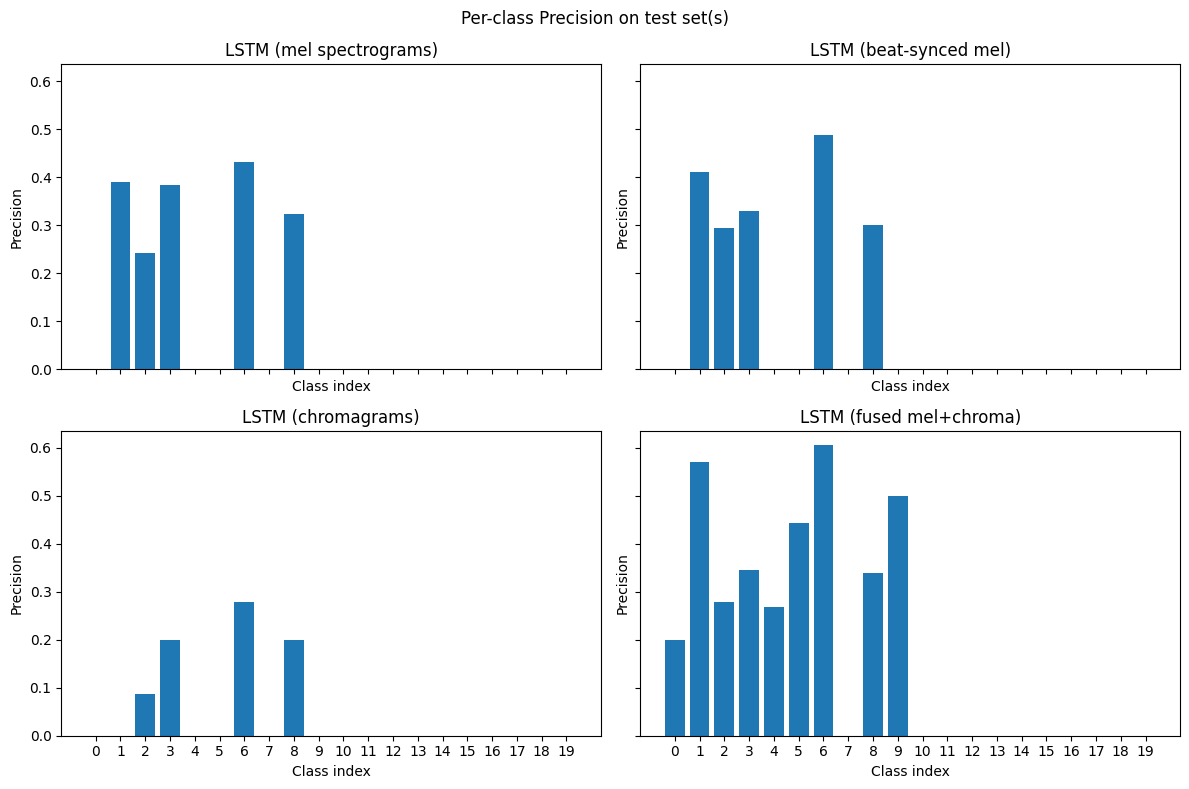

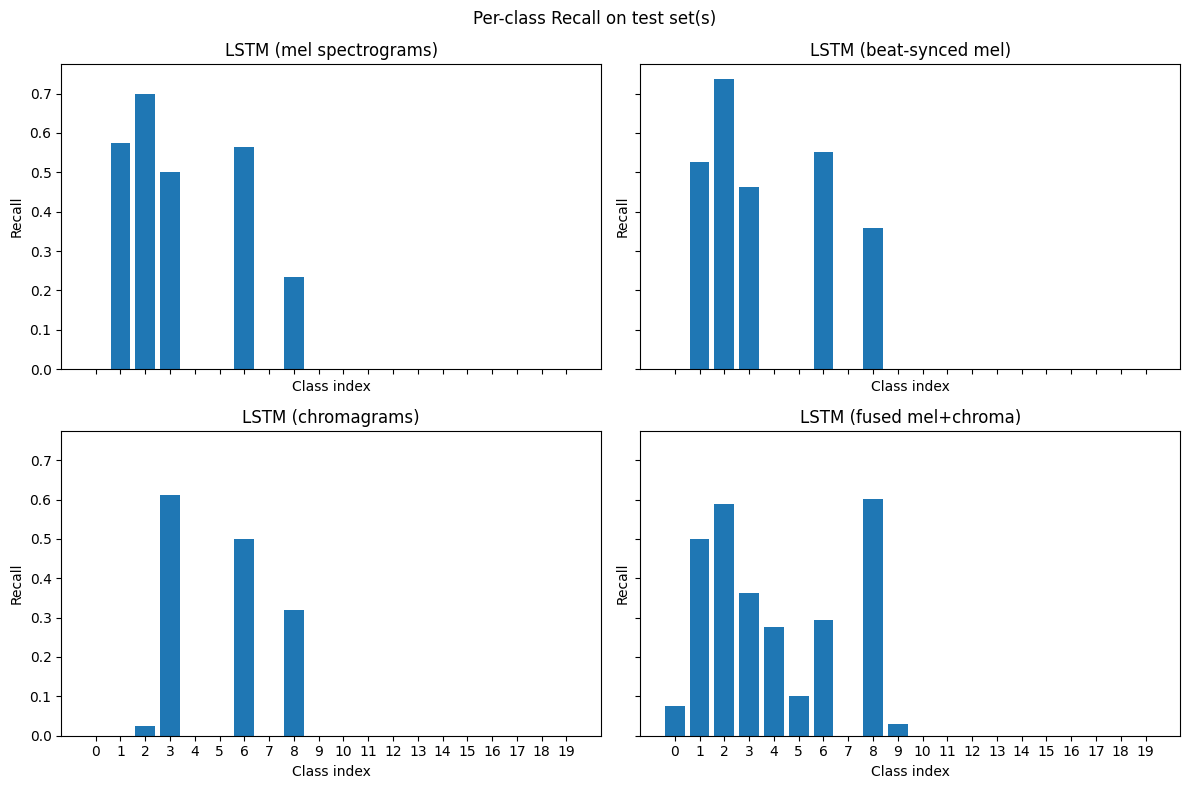

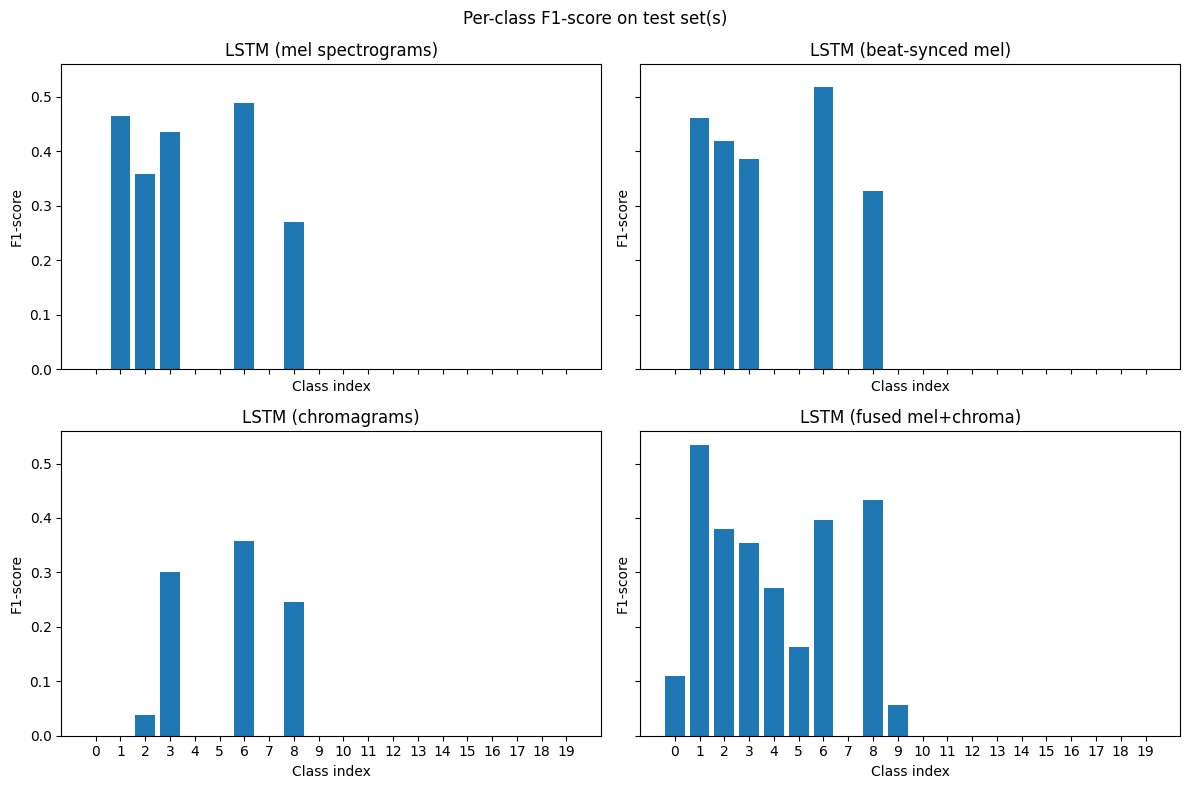

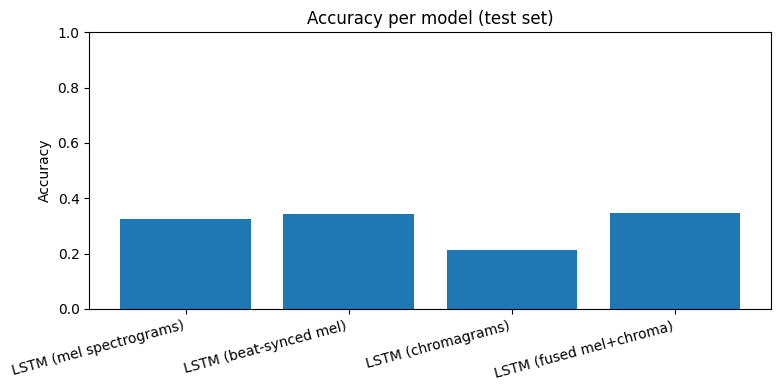

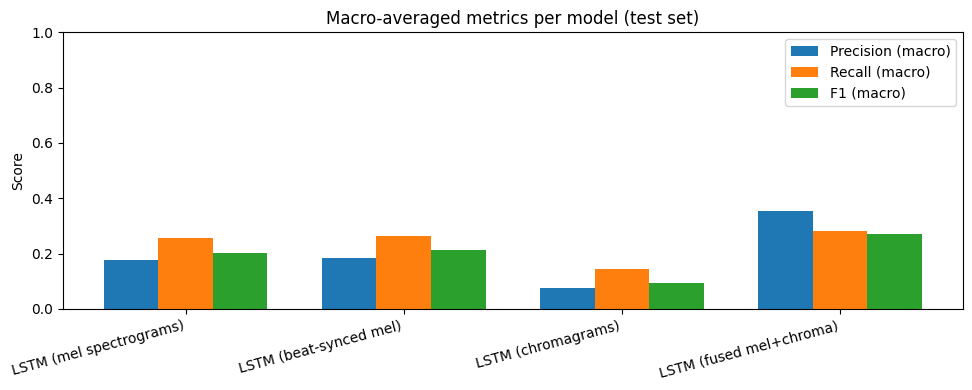

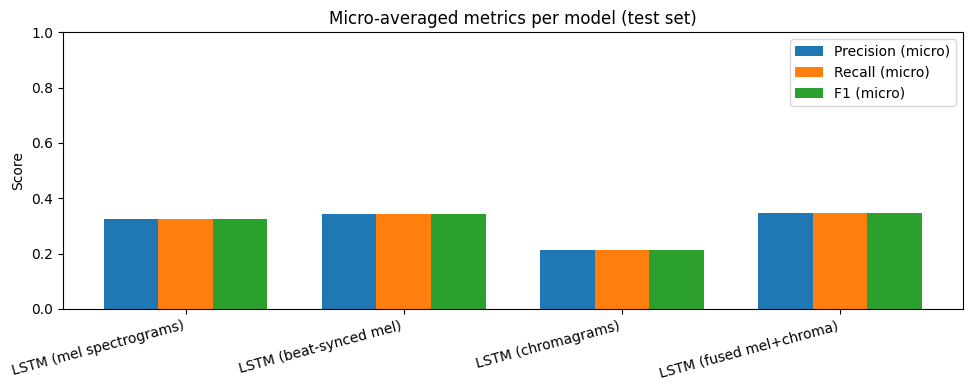

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

# Make sure this matches the hidden size used during training
RNN_HIDDEN_SIZE = 128

# ------------------------------------------
# Helper: get true & predicted labels
# (based on professor's helper code)
# ------------------------------------------
def get_labels_predictions(model, data_loader, device):
    """
    Run model on an entire DataLoader and collect:
      - true labels (y_true)
      - predicted labels (y_pred)
    """
    model.eval()
    y_true_batches = []
    y_pred_batches = []

    with torch.no_grad():
        for x, labels, lengths in data_loader:
            # Forward pass (same call signature as in training)
            loss, logits = model(
                x.float().to(device),
                labels.to(device),
                lengths.to(device),
            )
            # Append ground-truth labels
            y_true_batches.append(labels.cpu().numpy())
            # Append predicted class indices (argmax over logits)
            y_pred_batches.append(
                logits.argmax(dim=-1).detach().cpu().numpy()
            )

    # Concatenate batches into single 1D arrays
    y_true = np.hstack(y_true_batches)
    y_pred = np.hstack(y_pred_batches)
    return y_true, y_pred


# ------------------------------------------
# Helper: evaluate one saved model on a test set
# ------------------------------------------
def evaluate_model_on_test(
    data_root,
    feat_type,
    saved_model_path,
    model_name,
):
    """
    1. Build a SpectrogramDataset for the TEST split (train=False)
    2. Recreate the LSTMBackbone + Classifier (same architecture as in training)
    3. Load weights from `saved_model_path`
    4. Compute accuracy, macro/micro PRF, per-class PRF
    5. Return a metrics dict and print a textual report
    """
    print(f"\nEvaluation of model {model_name} on the test set...")

    # Test dataset (uses the appropriate *test_labels.txt* internally)
    test_dataset = SpectrogramDataset(
        data_root,
        class_mapping=CLASS_MAPPING,
        train=False,
        feat_type=feat_type,
        max_length=MAX_LENGTH,
    )

    # val_size=0.0 → loader is pure test set (no validation split)
    test_loader, _ = torch_train_val_split(
        test_dataset,
        BATCH_SIZE,
        BATCH_SIZE,
        val_size=0.0,
    )

    # Get feature dimension from one batch (T, D)
    x_b1, y_b1, lengths_b1 = next(iter(test_loader))
    input_shape = x_b1[0].shape

    # Recreate the backbone and classifier as in training
    backbone = LSTMBackbone(
        input_dim=input_shape[1],
        rnn_size=RNN_HIDDEN_SIZE,
        num_layers=2,
        bidirectional=True,
    )
    model = Classifier(NUM_CATEGORIES, backbone).to(DEVICE)
    model.load_state_dict(torch.load(saved_model_path, map_location=DEVICE))

    # Run model on all test batches and get labels / predictions
    y_true, y_pred = get_labels_predictions(model, test_loader, DEVICE)

    # Full classification report (per-class lines, plus macro/weighted)
    # We keep this for per-class diagnostics, but we will NOT use the
    # weighted average in our own metrics/plots.
    print(classification_report(y_true, y_pred, zero_division=0))

    # Overall accuracy
    acc = accuracy_score(y_true, y_pred)

    # classification_report as dict to grab per-class and macro values
    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    # Macro-averaged metrics (across classes, equal weight per class)
    prec_macro = report_dict["macro avg"]["precision"]
    rec_macro = report_dict["macro avg"]["recall"]
    f1_macro = report_dict["macro avg"]["f1-score"]

    # Micro-averaged metrics (global TP/FP/FN, equivalent to accuracy in multiclass)
    prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )

    # Explicitly print macro and micro averages
    print("Global metrics (macro & micro):")
    print(f"  Accuracy:    {acc:.3f}")
    print(
        f"  Macro-avg:   P={prec_macro:.3f}, "
        f"R={rec_macro:.3f}, F1={f1_macro:.3f}"
    )
    print(
        f"  Micro-avg:   P={prec_micro:.3f}, "
        f"R={rec_micro:.3f}, F1={f1_micro:.3f}"
    )

    # Per-class precision / recall / F1 (for plotting)
    per_class_precision = []
    per_class_recall = []
    per_class_f1 = []

    for c in range(NUM_CATEGORIES):
        key = str(c)
        if key in report_dict:
            per_class_precision.append(report_dict[key]["precision"])
            per_class_recall.append(report_dict[key]["recall"])
            per_class_f1.append(report_dict[key]["f1-score"])
        else:
            # If class is missing from report (no samples), define everything as 0
            per_class_precision.append(0.0)
            per_class_recall.append(0.0)
            per_class_f1.append(0.0)

    # Collect all metrics in a dictionary (NO weighted averages here)
    metrics = {
        "model_name": model_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_micro": prec_micro,
        "recall_micro": rec_micro,
        "f1_micro": f1_micro,
        "per_class_precision": per_class_precision,
        "per_class_recall": per_class_recall,
        "per_class_f1": per_class_f1,
    }
    return metrics


# ------------------------------------------
# 1) Evaluate all four models (Step 5) on test sets
# ------------------------------------------
# Original spectrograms test set (mel, chroma, fused)
metrics_mel = evaluate_model_on_test(
    data_root=MEL_ROOT,
    feat_type="mel",
    saved_model_path="lstm_genre_mel.pth",
    model_name="LSTM (mel spectrograms)",
)

metrics_chroma = evaluate_model_on_test(
    data_root=MEL_ROOT,
    feat_type="chroma",
    saved_model_path="lstm_genre_chroma.pth",
    model_name="LSTM (chromagrams)",
)

metrics_fused = evaluate_model_on_test(
    data_root=MEL_ROOT,
    feat_type="fused",
    saved_model_path="lstm_genre_fused.pth",
    model_name="LSTM (fused mel+chroma)",
)

# Beat-synced spectrograms test set (beat-mel)
metrics_beat_mel = evaluate_model_on_test(
    data_root=BEAT_ROOT,
    feat_type="mel",
    saved_model_path="lstm_genre_beat_mel.pth",
    model_name="LSTM (beat-synced mel)",
)

# Collect metrics for plotting
all_metrics = [
    metrics_mel,
    metrics_beat_mel,
    metrics_chroma,
    metrics_fused,
]
model_labels = [m["model_name"] for m in all_metrics]

# ------------------------------------------
# 2) Plot per-class Precision, Recall, F1 for each model
#    (three figures, each with 4 subplots)
# ------------------------------------------
num_classes = NUM_CATEGORIES
class_indices = np.arange(num_classes)

# (a) Per-class Precision
fig_p, axes_p = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_p = axes_p.ravel()
for ax, m in zip(axes_p, all_metrics):
    ax.bar(class_indices, m["per_class_precision"])
    ax.set_title(m["model_name"])
    ax.set_xlabel("Class index")
    ax.set_ylabel("Precision")
    ax.set_xticks(class_indices)
fig_p.suptitle("Per-class Precision on test set(s)")
plt.tight_layout()
plt.show()

# (b) Per-class Recall
fig_r, axes_r = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_r = axes_r.ravel()
for ax, m in zip(axes_r, all_metrics):
    ax.bar(class_indices, m["per_class_recall"])
    ax.set_title(m["model_name"])
    ax.set_xlabel("Class index")
    ax.set_ylabel("Recall")
    ax.set_xticks(class_indices)
fig_r.suptitle("Per-class Recall on test set(s)")
plt.tight_layout()
plt.show()

# (c) Per-class F1
fig_f, axes_f = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_f = axes_f.ravel()
for ax, m in zip(axes_f, all_metrics):
    ax.bar(class_indices, m["per_class_f1"])
    ax.set_title(m["model_name"])
    ax.set_xlabel("Class index")
    ax.set_ylabel("F1-score")
    ax.set_xticks(class_indices)
fig_f.suptitle("Per-class F1-score on test set(s)")
plt.tight_layout()
plt.show()

# ------------------------------------------
# 3) Overall diagrams — all global metrics per model
#    (Accuracy, macro P/R/F1, micro P/R/F1)
# ------------------------------------------
accs        = [m["accuracy"]          for m in all_metrics]
prec_macro  = [m["precision_macro"]   for m in all_metrics]
rec_macro   = [m["recall_macro"]      for m in all_metrics]
f1_macro    = [m["f1_macro"]          for m in all_metrics]
prec_micro  = [m["precision_micro"]   for m in all_metrics]
rec_micro   = [m["recall_micro"]      for m in all_metrics]
f1_micro    = [m["f1_micro"]          for m in all_metrics]

x = np.arange(len(model_labels))
width = 0.25  # bar width for grouped plots

# (1) Accuracy per model
fig_acc, ax_acc = plt.subplots(figsize=(8, 4))
ax_acc.bar(x, accs)
ax_acc.set_title("Accuracy per model (test set)")
ax_acc.set_xticks(x)
ax_acc.set_xticklabels(model_labels, rotation=15, ha="right")
ax_acc.set_ylim(0.0, 1.0)
ax_acc.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

# (2) Macro-averaged metrics (Precision/Recall/F1)
fig_macro, ax_macro = plt.subplots(figsize=(10, 4))
ax_macro.bar(x - width, prec_macro, width, label="Precision (macro)")
ax_macro.bar(x,         rec_macro,  width, label="Recall (macro)")
ax_macro.bar(x + width, f1_macro,   width, label="F1 (macro)")
ax_macro.set_title("Macro-averaged metrics per model (test set)")
ax_macro.set_xticks(x)
ax_macro.set_xticklabels(model_labels, rotation=15, ha="right")
ax_macro.set_ylim(0.0, 1.0)
ax_macro.set_ylabel("Score")
ax_macro.legend()
plt.tight_layout()
plt.show()

# (3) Micro-averaged metrics (Precision/Recall/F1)
fig_micro, ax_micro = plt.subplots(figsize=(10, 4))
ax_micro.bar(x - width, prec_micro, width, label="Precision (micro)")
ax_micro.bar(x,         rec_micro,  width, label="Recall (micro)")
ax_micro.bar(x + width, f1_micro,   width, label="F1 (micro)")
ax_micro.set_title("Micro-averaged metrics per model (test set)")
ax_micro.set_xticks(x)
ax_micro.set_xticklabels(model_labels, rotation=15, ha="right")
ax_micro.set_ylim(0.0, 1.0)
ax_micro.set_ylabel("Score")
ax_micro.legend()
plt.tight_layout()
plt.show()


## **Main Lab - Steps 7-10**

---

### **Step 7.1: 2D CNN**

---

In this step, we replace the LSTM backbone with a 2D CNN that treats each mel spectrogram as an image (1 × 128 × T).

1. **Model definition (cell 1).**  
   We implement the `CNNBackbone` with four convolutional blocks (filters `[32, 64, 128, 256]`, 5×5 / 3×3 kernels, batch‐norm, ReLU, max-pooling) and a final fully connected layer that produces a feature vector of size 1024. The backbone is wrapped in the existing `Classifier` so we can reuse the same training loop and loss as in Steps 5–6. Hyperparameters: Adam optimizer with learning rate of the order of 10⁻⁴, same `BATCH_SIZE` and `MAX_LENGTH` as before, and early stopping.

2. **Overfitting sanity check (cell 2).**  
   Using `overfit_batch=True,` we train the CNN on a single batch for 400 epochs. The training loss drops from ≈2.37 (almost random) to values around 10⁻⁷, showing that the CNN can perfectly memorize a tiny subset of the data and that the implementation of the model, loss and optimizer is correct.

3. **Full training and evaluation (cell 3).**  
   We then train the same CNN normally for up to 40 epochs on the full mel train set (with early stopping activated around epoch 18) and evaluate it on the corresponding mel test set. We compute the same metrics as in Step 6 (accuracy, micro/macro precision–recall–F1, and per-class scores) and plot a single confusion matrix for the test set so that we can directly compare the CNN with the LSTM models.


In [10]:
# ================================================================
# Step 7.1(b) — 2D CNN backbone + classifier & hyperparameters
# Treat spectrograms as single-channel images
# ================================================================
import torch
import torch.nn as nn

# -------------------------------
# 2D CNN backbone (helper-based)
# -------------------------------
class CNNBackbone(nn.Module):
    """
    CNN feature extractor that processes a spectrogram as a 2D image.

    input_dims : (H, W) = (freq_bins/time_steps, time_steps/freq_bins)
    in_channels : number of input channels (1 for mono spectrogram)
    filters : list with number of filters for each conv block
    feature_size : dimensionality of final feature vector
    """
    def __init__(self, input_dims, in_channels, filters, feature_size, dropout_p: float = 0.5):
        super(CNNBackbone, self).__init__()
        self.input_dims = input_dims
        self.in_channels = in_channels
        self.filters = filters
        self.feature_size = feature_size

        # 1st conv block: 5x5 kernels, BN, ReLU, 2x2 max-pooling
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, filters[0], kernel_size=(5, 5), stride=1, padding=2),
            nn.BatchNorm2d(filters[0]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 2nd conv block
        self.conv2 = nn.Sequential(
            nn.Conv2d(filters[0], filters[1], kernel_size=(5, 5), stride=1, padding=2),
            nn.BatchNorm2d(filters[1]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 3rd conv block: switch to 3x3 kernels (common in VGG-style CNNs)
        self.conv3 = nn.Sequential(
            nn.Conv2d(filters[1], filters[2], kernel_size=(3, 3), stride=1, padding=1),
            nn.BatchNorm2d(filters[2]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 4th conv block
        self.conv4 = nn.Sequential(
            nn.Conv2d(filters[2], filters[3], kernel_size=(3, 3), stride=1, padding=1),
            nn.BatchNorm2d(filters[3]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # After 4 max-poolings (2x2, stride 2) each spatial dimension is divided by 2^4 = 16
        h_after = input_dims[0] // (2 ** len(filters))
        w_after = input_dims[1] // (2 ** len(filters))
        flattened = filters[3] * h_after * w_after

        # Fully connected projection to a compact feature vector + dropout
        self.fc1 = nn.Sequential(
            nn.Linear(flattened, feature_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
        )

    def forward(self, x, lengths=None):
        """
        x : tensor of shape (batch_size, T, F) or (batch_size, H, W) from SpectrogramDataset
        lengths : kept for API compatibility with LSTM backbones; not used here.
        """
        # Add the channel dimension: (B, H, W) -> (B, C=1, H, W)
        x = x.view(x.shape[0], self.in_channels, x.shape[1], x.shape[2])

        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.conv4(out)

        # Flatten spatial dimensions
        out = out.view(out.size(0), -1)

        # Final feature vector
        out = self.fc1(out)
        return out


# ================================================================
# Hyperparameters for CNN classifier (genre recognition)
# ================================================================

# Device: use GPU when available (hint from steps 5 & 7.1)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Number of music genres (same as in previous steps / FMA mapping)
NUM_CATEGORIES = 10

# CNN architecture parameters (based on common audio-CNN setups)
# 4 conv blocks with increasing filters, 3x3 / 5x5 kernels
CNN_IN_CHANNELS = 1
CNN_FILTERS = [32, 64, 128, 256]
CNN_FEATURE_SIZE = 1024  # size of latent representation before Classifier

# Optimization hyperparameters (Adam, small LR, mild weight decay)
CNN_LR = 3e-4           # typical LR for Adam on CNNs with spectrograms
CNN_WEIGHT_DECAY = 1e-4 # L2 regularization
CNN_EPOCHS = 40         # fewer epochs than LSTM, model is heavier

# ------------------------------------------------------------
# Get input spectrogram shape from the existing train_loader
# (we re-use the same loaders as in Step 5a: mel spectrograms)
# ------------------------------------------------------------
x_b1, y_b1, lengths_b1 = next(iter(train_loader))
input_shape = x_b1[0].shape  # (H, W) for a single spectrogram

# Backbone & full classifier model
cnn_backbone = CNNBackbone(
    input_dims=input_shape,
    in_channels=CNN_IN_CHANNELS,
    filters=CNN_FILTERS,
    feature_size=CNN_FEATURE_SIZE,
)

# Classifier class is already defined in earlier steps; we just reuse it.
cnn_model = Classifier(NUM_CATEGORIES, cnn_backbone).to(DEVICE)

# Adam optimizer as requested in the hints
cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=CNN_LR,
    weight_decay=CNN_WEIGHT_DECAY,
)


In [19]:
# ================================================================
# Step 7.1(d) — Overfit on a single batch to sanity-check the CNN
# ================================================================

# Number of epochs just for overfitting a single batch
EPOCHS_OVERFIT = 400

# For the overfit experiment we create a *fresh* CNN model
cnn_overfit_backbone = CNNBackbone(
    input_dims=input_shape,
    in_channels=CNN_IN_CHANNELS,
    filters=CNN_FILTERS,
    feature_size=CNN_FEATURE_SIZE,
)
cnn_overfit_model = Classifier(NUM_CATEGORIES, cnn_overfit_backbone).to(DEVICE)

cnn_overfit_optimizer = torch.optim.Adam(
    cnn_overfit_model.parameters(),
    lr=CNN_LR,
    weight_decay=CNN_WEIGHT_DECAY,
)

# Train using exactly the same train() utility as in Step 5,
# but with overfit_batch=True so that it repeatedly trains on
# a single mini-batch until it drives the training loss to ~0.
train(
    cnn_overfit_model,
    train_loader,
    val_loader,
    cnn_overfit_optimizer,
    EPOCHS_OVERFIT,
    device=DEVICE,
    overfit_batch=True,
)


Training in overfitting mode...
Epoch 1, Loss at training set: 2.3693900108337402
Epoch 20, Loss at training set: 0.00016072097059804946
Epoch 40, Loss at training set: 0.001349158468656242
Epoch 60, Loss at training set: 0.0003072692488785833
Epoch 80, Loss at training set: 5.662428179675771e-07
Epoch 100, Loss at training set: 4.1424545997870155e-06
Epoch 120, Loss at training set: 2.086160861836106e-07
Epoch 140, Loss at training set: 3.27825119939007e-07
Epoch 160, Loss at training set: 4.470348002882929e-08
Epoch 180, Loss at training set: 1.1175841336807935e-06
Epoch 200, Loss at training set: 7.450558427990472e-07
Epoch 220, Loss at training set: 4.574614649754949e-06
Epoch 240, Loss at training set: 1.6391271628890536e-07
Epoch 260, Loss at training set: 2.846089728336665e-06
Epoch 280, Loss at training set: 3.576274707484117e-07
Epoch 300, Loss at training set: 7.450579175838357e-08
Epoch 320, Loss at training set: 6.6755419538822025e-06
Epoch 340, Loss at training set: 3.7252

Training started for model checkpoint...
Epoch 1/40, Loss at training set: 2.5647
	Loss at validation set: 1.9355
Epoch 5/40, Loss at training set: 1.8765
	Loss at validation set: 1.7329
Epoch 10/40, Loss at training set: 1.7236
	Loss at validation set: 2.3396
Epoch 15/40, Loss at training set: 1.6056
	Loss at validation set: 1.6817
Early Stopping was activated.
Epoch 18/40, Loss at training set: 1.5068
	Loss at validation set: 1.5901
Training has been completed.


===== Test results (CNN) =====
Accuracy: 0.4157
Micro-avg  P/R/F1: 0.4157 / 0.4157 / 0.4157
Macro-avg  P/R/F1: 0.3280 / 0.3624 / 0.3312

Per-class metrics (classification_report):
              precision    recall  f1-score   support

           0     0.1538    0.0500    0.0755        40
           1     0.4894    0.5750    0.5287        40
           2     0.4274    0.6625    0.5196        80
           3     0.3852    0.5875    0.4653        80
           4     0.4783    0.5500    0.5116        40
           5     0.1000  

<Figure size 700x600 with 0 Axes>

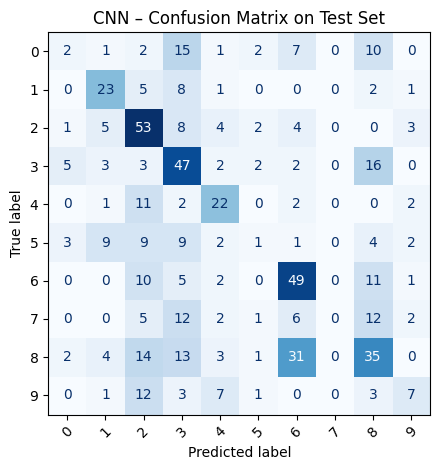

In [20]:
# ================================================================
# Step 7.1(e) — Train CNN on full data, evaluate on TEST set only,
#               and print Step-6-style metrics + confusion matrix
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from dataset import CLASS_MAPPING, SpectrogramDataset, torch_train_val_split

# ------------------------------------------------------------
# 0) DataLoaders for CNN
#    Reuse existing TRAIN / VAL loaders (mel spectrograms)
# ------------------------------------------------------------
train_loader_cnn = train_loader   # from previous steps
val_loader_cnn   = val_loader     # used only inside train()

# Build a TEST loader with the same configuration (mel features)
test_dataset_cnn = SpectrogramDataset(
    MEL_ROOT,
    class_mapping=CLASS_MAPPING,
    train=False,          # uses test_labels.txt internally
    feat_type="mel",
    max_length=MAX_LENGTH,
)

test_loader_cnn, _ = torch_train_val_split(
    test_dataset_cnn,
    BATCH_SIZE,
    BATCH_SIZE,
    val_size=0.0,         # pure test set, no validation split
)

# ------------------------------------------------------------
# 1) Train the main CNN (normal mode, not overfitting)
# ------------------------------------------------------------
train(
    cnn_model,
    train_loader_cnn,
    val_loader_cnn,
    cnn_optimizer,
    CNN_EPOCHS,
    device=DEVICE,
    overfit_batch=False,   # full training over whole dataset
)

# ------------------------------------------------------------
# 2) Helper: evaluate model on TEST set
#    Classifier.forward(x, targets, lengths) -> (loss, logits)
#    We cast xb to float32 and yb to long to match Conv2d + CE loss.
# ------------------------------------------------------------
def evaluate_cnn_on_test(model, data_loader, device, num_classes, split_name="Test"):
    model.eval()
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            # Our SpectrogramDataset returns (x, y, lengths)
            if len(batch) == 3:
                xb, yb, lengths = batch
            else:
                xb, yb = batch
                lengths = None

            # Move to device and cast to correct dtypes
            xb = xb.to(device).float()  # Conv2d expects float32
            yb = yb.to(device).long()   # CrossEntropyLoss expects long

            # Classifier.forward(x, targets, lengths) in this notebook
            loss, logits = model(xb, yb, lengths)

            # Predictions from logits
            preds = torch.argmax(logits, dim=1)

            all_targets.append(yb.cpu())
            all_preds.append(preds.cpu())

    # Concatenate all batches
    all_targets = torch.cat(all_targets).numpy()
    all_preds   = torch.cat(all_preds).numpy()

    # ---------------- Metrics in the style of Step 6 ----------------
    # Overall accuracy
    acc = accuracy_score(all_targets, all_preds)

    # Micro-averaged precision / recall / F1
    p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="micro", zero_division=0
    )

    # Macro-averaged precision / recall / F1
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )

    print(f"\n===== {split_name} results (CNN) =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Micro-avg  P/R/F1: {p_micro:.4f} / {r_micro:.4f} / {f1_micro:.4f}")
    print(f"Macro-avg  P/R/F1: {p_macro:.4f} / {r_macro:.4f} / {f1_macro:.4f}")

    # Per-class metrics (precision, recall, F1) like in Step 6
    print("\nPer-class metrics (classification_report):")
    print(classification_report(all_targets, all_preds, digits=4, zero_division=0))

    return acc, all_targets, all_preds


# ------------------------------------------------------------
# 3) Evaluate ONLY on TEST set
# ------------------------------------------------------------
cnn_test_acc, cnn_test_y_true, cnn_test_y_pred = evaluate_cnn_on_test(
    cnn_model, test_loader_cnn, DEVICE, NUM_CATEGORIES, split_name="Test"
)

# ------------------------------------------------------------
# 4) Confusion matrix on the TEST set (single overall diagram)
# ------------------------------------------------------------
cm = confusion_matrix(cnn_test_y_true, cnn_test_y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("CNN – Confusion Matrix on Test Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Step 7.2: AST – Audio Spectrogram Transformer**

---

- **Cell 1 – Definition of AST and configuration**  
  We incorporate the instructor’s implementation of `ASTBackbone`, adapting it to the Kaggle environment using the `timm` library.  
  We load the pretrained model `deit_base_distilled_patch16_384` (trained on ImageNet), which accepts single-channel mel-spectrograms (T × F) treated as images and outputs 1024-dimensional feature embeddings.  
  We define two `Classifier` heads on top of the AST (one for overfitting experiments and one for full training), using LR = 1e−4, a maximum of 40 epochs, and a dedicated Adam optimizer for each.  
  The `train_loader_ast`, `val_loader_ast`, and `test_loader_ast` are the same as in previous steps, ensuring that AST results are directly comparable to the LSTMs and 2D CNN.

- **Cell 2 – Overfitting experiment**  
  We train `ast_model_overfit` on a very small subset of the training set (`overfit_batch=True`) for 400 epochs.  
  The training loss drops quickly to extremely small values (~2×10⁻⁵), demonstrating that the AST combined with the classifier and training routine can perfectly memorize a few examples and that forward/backpropagation are implemented correctly.

- **Cell 3 – Full training and evaluation**  
  We train the main `ast_model` on the full training set for up to 40 epochs, using early stopping based on validation loss (training stops at epoch 8 when the validation loss begins to increase).  
  We then evaluate the model on the test set using the same procedure as in Steps 6 and 7.1: we compute accuracy, micro/macro precision, recall, and F1, print the full per-class `classification_report`, and plot the confusion matrix (“AST – Confusion Matrix on Test Set”) for direct comparison against the LSTM models and the 2D CNN.


In [12]:
# ==============================================================
# Step 7.2 – AST (Audio Spectrogram Transformer) helper + setup
# ==============================================================

import torch
import torch.nn as nn
import timm
from timm.layers import to_2tuple, trunc_normal_

# --------------------------------------------------------------
# Override the timm PatchEmbed to relax the input shape constraint
# (this class is kept for compatibility with the original code)
# --------------------------------------------------------------
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        # Convolutional projection that creates patch embeddings
        self.proj = nn.Conv2d(
            in_chans,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        # x: (B, C, H, W) → conv → flatten spatial dims → (B, N_patches, embed_dim)
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x


class ASTBackbone(nn.Module):
    """
    The AST model.

    :param fstride: stride of patch splitting on frequency dimension.
    :param tstride: stride of patch splitting on time dimension.
    :param input_fdim: number of frequency bins of the input spectrogram.
    :param input_tdim: number of time frames of the input spectrogram.
    :param imagenet_pretrain: whether to use ImageNet pretrained ViT.
    :param model_size: one of ['tiny224', 'small224', 'base224', 'base384'].
    :param feature_size: size of the final feature vector produced by AST.
    """
    def __init__(
        self,
        fstride=10,
        tstride=10,
        input_fdim=128,
        input_tdim=1024,
        imagenet_pretrain=True,
        model_size='base384',
        feature_size=1000,
    ):
        super(ASTBackbone, self).__init__()

        # Override timm's internal PatchEmbed class globally (for older timm)
        timm.models.vision_transformer.PatchEmbed = PatchEmbed

        # ----------------------------------------------------------
        # Map model_size → valid timm model names (for timm>=1.0)
        # (original code used 'vit_deit_*', which no longer exist)
        # ----------------------------------------------------------
        if model_size == 'tiny224':
            backbone_name = 'deit_tiny_distilled_patch16_224'
        elif model_size == 'small224':
            backbone_name = 'deit_small_distilled_patch16_224'
        elif model_size == 'base224':
            backbone_name = 'deit_base_distilled_patch16_224'
        elif model_size == 'base384':
            backbone_name = 'deit_base_distilled_patch16_384'
        else:
            raise Exception(
                'Model size must be one of tiny224, small224, base224, base384.'
            )

        # Create ViT/DeiT backbone
        self.v = timm.create_model(
            backbone_name,
            pretrained=imagenet_pretrain,
        )

        if hasattr(self.v, "patch_embed"):
            # Disable strict checks on the input size
            if hasattr(self.v.patch_embed, "img_size"):
                self.v.patch_embed.img_size = None  # no fixed img size
            if hasattr(self.v.patch_embed, "strict_img_size"):
                self.v.patch_embed.strict_img_size = False
        # -------------------------------------------------

        self.feature_size = feature_size
        self.original_num_patches = self.v.patch_embed.num_patches
        self.oringal_hw = int(self.original_num_patches ** 0.5)
        self.original_embedding_dim = self.v.pos_embed.shape[2]

        # MLP head that maps ViT embedding → feature_size
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(self.original_embedding_dim),
            nn.Linear(self.original_embedding_dim, self.feature_size),
        )

        # Automatically compute new patch grid size (f_dim × t_dim) for audio
        f_dim, t_dim = self.get_shape(
            fstride,
            tstride,
            input_fdim,
            input_tdim,
        )
        num_patches = f_dim * t_dim
        self.v.patch_embed.num_patches = num_patches

        # Linear projection layer from 1-channel spectrogram to ViT embedding dim
        new_proj = nn.Conv2d(
            1,
            self.original_embedding_dim,
            kernel_size=(16, 16),
            stride=(fstride, tstride),
        )

        if imagenet_pretrain:
            # Collapse the 3 RGB filters into a single channel by summing over channels
            new_proj.weight = nn.Parameter(
                torch.sum(self.v.patch_embed.proj.weight, dim=1).unsqueeze(1)
            )
            new_proj.bias = self.v.patch_embed.proj.bias

        self.v.patch_embed.proj = new_proj

        # Positional embedding adaptation from image ViT to audio patch grid
        if imagenet_pretrain:
            # Take positional embeddings (skip [CLS] and distillation tokens)
            new_pos_embed = (
                self.v.pos_embed[:, 2:, :]
                .detach()
                .reshape(1, self.original_num_patches, self.original_embedding_dim)
                .transpose(1, 2)
                .reshape(
                    1,
                    self.original_embedding_dim,
                    self.oringal_hw,
                    self.oringal_hw,
                )
            )

            # Adjust time dimension (second spatial dim)
            if t_dim <= self.oringal_hw:
                # Center crop
                new_pos_embed = new_pos_embed[
                    :,
                    :,
                    :,
                    int(self.oringal_hw / 2) - int(t_dim / 2) :
                    int(self.oringal_hw / 2) - int(t_dim / 2) + t_dim,
                ]
            else:
                # Bilinear interpolation
                new_pos_embed = torch.nn.functional.interpolate(
                    new_pos_embed,
                    size=(self.oringal_hw, t_dim),
                    mode='bilinear',
                )

            # Adjust frequency dimension (first spatial dim)
            if f_dim <= self.oringal_hw:
                new_pos_embed = new_pos_embed[
                    :,
                    :,
                    int(self.oringal_hw / 2) - int(f_dim / 2) :
                    int(self.oringal_hw / 2) - int(f_dim / 2) + f_dim,
                    :,
                ]
            else:
                new_pos_embed = torch.nn.functional.interpolate(
                    new_pos_embed,
                    size=(f_dim, t_dim),
                )

            # Flatten back to (1, num_patches, embed_dim)
            new_pos_embed = new_pos_embed.reshape(
                1,
                self.original_embedding_dim,
                num_patches,
            ).transpose(1, 2)

            # Concatenate with existing [CLS] and distillation token embeddings
            self.v.pos_embed = nn.Parameter(
                torch.cat(
                    [self.v.pos_embed[:, :2, :].detach(), new_pos_embed],
                    dim=1,
                )
            )
        else:
            # Randomly initialize positional embeddings if not using ImageNet pretrain
            new_pos_embed = nn.Parameter(
                torch.zeros(
                    1,
                    self.v.patch_embed.num_patches + 2,
                    self.original_embedding_dim,
                )
            )
            self.v.pos_embed = new_pos_embed
            trunc_normal_(self.v.pos_embed, std=0.02)

    def get_shape(
        self,
        fstride,
        tstride,
        input_fdim=128,
        input_tdim=1024,
    ):
        """
        Compute resulting (f_dim, t_dim) after conv with given strides.
        """
        test_input = torch.randn(1, 1, input_fdim, input_tdim)
        test_proj = nn.Conv2d(
            1,
            self.original_embedding_dim,
            kernel_size=(16, 16),
            stride=(fstride, tstride),
        )
        test_out = test_proj(test_input)
        f_dim = test_out.shape[2]
        t_dim = test_out.shape[3]
        return f_dim, t_dim

    def forward(self, x):
        """
        :param x: input spectrogram, expected shape: (B, T, F),
                  e.g., (12, 1024, 128)
        :return: feature vector of shape (B, feature_size)
        """
        # Expect x: (B, T, F) – convert to (B, 1, F, T) for ViT
        x = x.unsqueeze(1)      # (B, 1, T, F)
        x = x.transpose(2, 3)   # (B, 1, F, T)

        B = x.shape[0]

        # Patch embedding
        x = self.v.patch_embed(x)  # (B, N_patches, embed_dim)

        # Add [CLS] and distillation tokens
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        dist_token = self.v.dist_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, dist_token, x), dim=1)

        # Add positional embeddings
        x = x + self.v.pos_embed
        x = self.v.pos_drop(x)

        # Transformer encoder blocks
        for blk in self.v.blocks:
            x = blk(x)

        x = self.v.norm(x)

        # Average of CLS and distillation token embeddings
        x = (x[:, 0] + x[:, 1]) / 2

        # Map to final feature_size
        x = self.mlp_head(x)

        # Return feature vector as float32
        return x.float()


# ==============================================================
# 1) AST setup: DataLoaders, hyperparameters, models
# ==============================================================

from dataset import SpectrogramDataset, CLASS_MAPPING, torch_train_val_split

# Reuse global configuration from previous steps if available
DEVICE = DEVICE if "DEVICE" in globals() else (
    "cuda" if torch.cuda.is_available() else "cpu"
)
NUM_CATEGORIES = NUM_CATEGORIES if "NUM_CATEGORIES" in globals() else 10

# --------------------------------------------------------------
# Reuse train/val loaders (mel spectrograms) from LSTM/CNN steps
# --------------------------------------------------------------
train_loader_ast = train_loader
val_loader_ast   = val_loader

# Build a fresh TEST loader for mel spectrograms
test_dataset_ast = SpectrogramDataset(
    MEL_ROOT,
    class_mapping=CLASS_MAPPING,
    train=False,          # uses test_labels.txt
    feat_type="mel",
    max_length=MAX_LENGTH,
)

test_loader_ast, _ = torch_train_val_split(
    test_dataset_ast,
    BATCH_SIZE,
    BATCH_SIZE,
    val_size=0.0,         # pure test set
)

# --------------------------------------------------------------
# Infer AST input dimensions from one batch
# --------------------------------------------------------------
x_b, y_b, lengths_b = next(iter(train_loader_ast))
# x_b: (batch_size, T, D) => T = time frames, D = mel bins
AST_INPUT_TDIM = x_b.shape[1]   # number of time frames
AST_INPUT_FDIM = x_b.shape[2]   # number of mel bins (128)

# --------------------------------------------------------------
# AST hyperparameters
# --------------------------------------------------------------
AST_FEATURE_SIZE    = 1024   # size of feature vector from AST backbone
AST_LR              = 1e-4   # same order of LR as LSTM/CNN
AST_EPOCHS          = 40     # to compare directly with 40-epoch LSTM/CNN runs
AST_OVERFIT_EPOCHS  = 400    # overfitting sanity check

# --------------------------------------------------------------
# Build two AST-based classifiers:
#   • ast_model_overfit : used only for overfitting
#   • ast_model         : used for main training + evaluation
# --------------------------------------------------------------

# AST backbone for the overfitting experiment
ast_backbone_overfit = ASTBackbone(
    input_fdim=AST_INPUT_FDIM,
    input_tdim=AST_INPUT_TDIM,
    imagenet_pretrain=True,
    model_size="base384",
    feature_size=AST_FEATURE_SIZE,
)

# Classifier is the same wrapper used for LSTM/CNN in previous steps
ast_model_overfit = Classifier(
    NUM_CATEGORIES,
    ast_backbone_overfit,
).to(DEVICE)

optimizer_ast_overfit = torch.optim.Adam(
    ast_model_overfit.parameters(),
    lr=AST_LR,
)

# AST backbone for the main experiment
ast_backbone = ASTBackbone(
    input_fdim=AST_INPUT_FDIM,
    input_tdim=AST_INPUT_TDIM,
    imagenet_pretrain=True,
    model_size="base384",
    feature_size=AST_FEATURE_SIZE,
)

ast_model = Classifier(
    NUM_CATEGORIES,
    ast_backbone,
).to(DEVICE)

optimizer_ast = torch.optim.Adam(
    ast_model.parameters(),
    lr=AST_LR,
)


In [27]:
# ==============================================================
# Step 7.2 – Overfitting experiment for AST
# ==============================================================

print("Training AST in overfitting mode (few batches)...")

train(
    ast_model_overfit,      # model to overfit
    train_loader_ast,       # full train loader (train() will internally pick a tiny subset)
    val_loader_ast,         # still passed to keep the same interface; not really used here
    optimizer_ast_overfit,  # optimizer for the overfit model
    AST_OVERFIT_EPOCHS,     # many epochs on the same few batches
    device=DEVICE,
    overfit_batch=True      # activates the special overfitting routine from Step 5
)


Training AST in overfitting mode (few batches)...
Training in overfitting mode...
Epoch 1, Loss at training set: 2.2483551502227783
Epoch 20, Loss at training set: 0.00385733088478446
Epoch 40, Loss at training set: 0.0004528808640316129
Epoch 60, Loss at training set: 0.0002146259939763695
Epoch 80, Loss at training set: 0.0001483885571360588
Epoch 100, Loss at training set: 0.00011553618242032826
Epoch 120, Loss at training set: 9.376806701766327e-05
Epoch 140, Loss at training set: 7.822761835996062e-05
Epoch 160, Loss at training set: 6.669505091849715e-05
Epoch 180, Loss at training set: 5.785928078694269e-05
Epoch 200, Loss at training set: 5.0930673751281574e-05
Epoch 220, Loss at training set: 4.5357948692981154e-05
Epoch 240, Loss at training set: 4.078352139913477e-05
Epoch 260, Loss at training set: 3.699879380292259e-05
Epoch 280, Loss at training set: 3.386968091945164e-05
Epoch 300, Loss at training set: 3.1142870284384117e-05
Epoch 320, Loss at training set: 2.8863072657

Training started for AST model checkpoint...
Training started for model checkpoint...
Epoch 1/40, Loss at training set: 2.0482
	Loss at validation set: 1.7461
Epoch 5/40, Loss at training set: 0.8648
	Loss at validation set: 1.9332
Early Stopping was activated.
Epoch 8/40, Loss at training set: 0.1579
	Loss at validation set: 3.3137
Training has been completed.

Training has been completed.

===== Test (AST) results (CNN) =====
Accuracy: 0.3757
Micro-avg  P/R/F1: 0.3757 / 0.3757 / 0.3757
Macro-avg  P/R/F1: 0.3365 / 0.3381 / 0.3261

Per-class metrics (classification_report):
              precision    recall  f1-score   support

           0     0.1212    0.1000    0.1096        40
           1     0.4783    0.5500    0.5116        40
           2     0.4035    0.5750    0.4742        80
           3     0.4483    0.3250    0.3768        80
           4     0.3571    0.5000    0.4167        40
           5     0.1786    0.1250    0.1471        40
           6     0.4694    0.5897    0.5

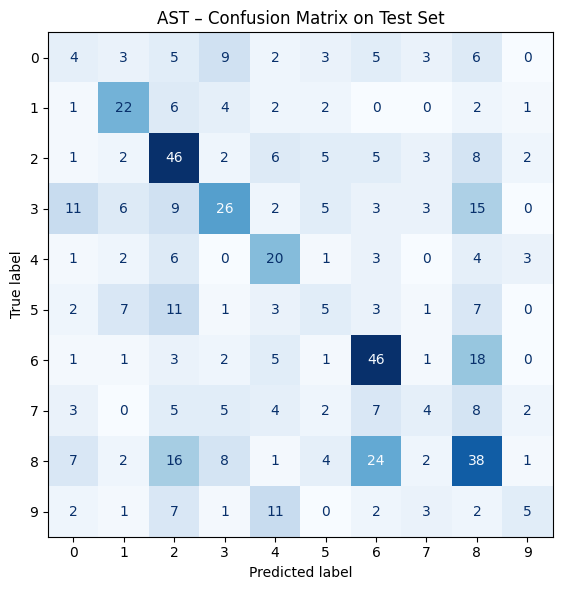

In [30]:
# ==============================================================
# Step 7.2 – AST main training and evaluation on the TEST set
# ==============================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1) Train the AST model on the full training set
# --------------------------------------------------------------
print("Training started for AST model checkpoint...")

# NOTE: train() itself prints "Training started for model ..." and
#       per-epoch losses + early stopping messages, exactly as in 7.1.
train(
    ast_model,          # main AST classifier
    train_loader_ast,   # training data (mel spectrograms)
    val_loader_ast,     # validation data for early stopping
    optimizer_ast,      # Adam optimizer
    AST_EPOCHS,
    device=DEVICE,
    overfit_batch=False # normal training mode
)

print("Training has been completed.")

# --------------------------------------------------------------
# 2) Evaluate on the TEST set (same protocol as Step 6 / 7.1)
# --------------------------------------------------------------
# evaluate_cnn_on_test:
#   • prints accuracy, micro/macro P/R/F1, classification_report
#   • returns (acc, y_true, y_pred) for further processing.
ast_test_acc, ast_test_y_true, ast_test_y_pred = evaluate_cnn_on_test(
    ast_model,
    test_loader_ast,
    DEVICE,
    NUM_CATEGORIES,
    split_name="Test (AST)"
)

# --------------------------------------------------------------
# 3) Confusion matrix (single overall diagram)
# --------------------------------------------------------------
cm = confusion_matrix(
    ast_test_y_true,
    ast_test_y_pred,
    labels=list(range(NUM_CATEGORIES))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(NUM_CATEGORIES))
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("AST – Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


### **Step 8: Estimating emotion and behavior using regression**

---

This cell builds a **mel-only multitask dataset** using  
`multitask_dataset/train_labels.txt` together with the fused `.npy` spectrogram files.  
All sequences are **padded or truncated to MAX_LENGTH**, and the dataset is split into  
**70% train / 15% validation / 15% test**.

For each target axis (**valence**, **energy**, **danceability**), the code:

- reuses the **same LSTM, CNN, and AST backbones** defined in Steps 5 and 7,  
- wraps each backbone with the provided **Regressor** module  
  (a Linear layer trained with **MSE loss**),  
- trains using **early stopping** based on validation MSE,  
- evaluates on the held-out test split, computing  
  **MSE** and **Spearman correlation** for each model and each axis.

All metrics are stored in `all_results`.  
After training/evaluation completes, the cell:

- prints the **mean Spearman** across the three axes for each model, and  
- plots a **grouped bar chart** of test-set Spearman values, comparing  
  **LSTM vs CNN vs AST** on valence, energy, and danceability.
  



================ Regression for valence ================

>>> Training LSTM regressor for valence
[001/40] train_loss=0.0782 val_loss=0.0679
[005/40] train_loss=0.0594 val_loss=0.0702
[010/40] train_loss=0.0560 val_loss=0.0669
[015/40] train_loss=0.0557 val_loss=0.0721
Early stopping at epoch 17 (val_loss=0.0720)
valence – LSTM | test MSE: 0.0689 | Spearman: 0.2308

>>> Training CNN regressor for valence
[001/40] train_loss=8.4996 val_loss=0.0781
[005/40] train_loss=0.0789 val_loss=0.0618
[010/40] train_loss=0.0802 val_loss=0.0635
Early stopping at epoch 10 (val_loss=0.0635)
valence – CNN | test MSE: 0.0668 | Spearman: 0.3120

>>> Training AST regressor for valence
[001/40] train_loss=0.2173 val_loss=0.0650
[005/40] train_loss=0.0549 val_loss=0.0475
[010/40] train_loss=0.0082 val_loss=0.0514
Early stopping at epoch 10 (val_loss=0.0514)
valence – AST | test MSE: 0.0511 | Spearman: 0.5795

================ Regression for energy ================

>>> Training LSTM regressor for energy
[0

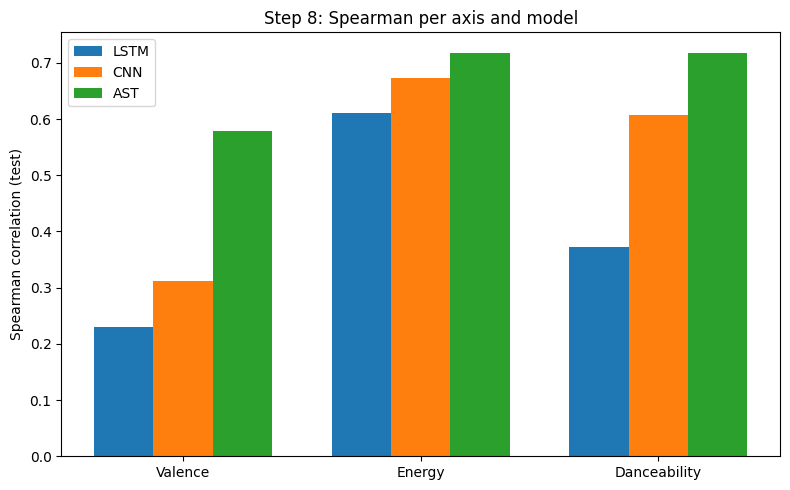

In [15]:
# ===================================================================================
# Step 8 – regression for valence / energy / danceability on the multitask dataset.
# ===================================================================================

import copy
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

from dataset import SpectrogramDataset
from lstm import LSTMBackbone


# Regressor wrapper provided by the instructor (slightly guarded for checkpoints)
class Regressor(nn.Module):
    def __init__(self, backbone, load_from_checkpoint=None):
        super(Regressor, self).__init__()
        self.backbone = backbone
        if load_from_checkpoint is not None:
            # load_backbone_from_checkpoint is available in the helper modules
            from modules import load_backbone_from_checkpoint

            self.backbone = load_backbone_from_checkpoint(
                self.backbone, load_from_checkpoint
            )
        self.is_lstm = isinstance(self.backbone, LSTMBackbone)
        self.output_layer = nn.Linear(self.backbone.feature_size, 1)
        self.criterion = nn.MSELoss()

    def forward(self, x, targets, lengths):
        feats = self.backbone(x) if not self.is_lstm else self.backbone(x, lengths)
        out = self.output_layer(feats)
        loss = self.criterion(out.float(), targets.float())
        return loss, out


# ------------------------------------------------------------------
# Configuration (reuses values from previous steps when present)
# ------------------------------------------------------------------
DEVICE = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = globals().get("BATCH_SIZE", 8)
MAX_LENGTH = globals().get("MAX_LENGTH", 150)
LR = globals().get("LR", 1e-4)
EPOCHS = globals().get("EPOCHS", 40)

CNN_IN_CHANNELS = globals().get("CNN_IN_CHANNELS", 1)
CNN_FILTERS = globals().get("CNN_FILTERS", [32, 64, 128, 256])
CNN_FEATURE_SIZE = globals().get("CNN_FEATURE_SIZE", 1024)
CNN_LR = globals().get("CNN_LR", 3e-4)
CNN_WEIGHT_DECAY = globals().get("CNN_WEIGHT_DECAY", 1e-4)

AST_FEATURE_SIZE = globals().get("AST_FEATURE_SIZE", 1024)
AST_LR = globals().get("AST_LR", 1e-4)

PARENT_DATA_DIR = globals().get(
    "PARENT_DATA_DIR", "../input/patreco3-multitask-affective-music/data/"
)
MULTITASK_ROOT = os.path.join(PARENT_DATA_DIR, "multitask_dataset")

REGRESSION_LABELS = {
    "valence": 1,
    "energy": 2,
    "danceability": 3,
}

# We keep mel-only features to stay consistent with Steps 5/7 inputs
REG_FEAT_TYPE = "mel"


def build_regression_loaders(target_name, batch_size=BATCH_SIZE, seed=42):
    """
    Create train/val/test loaders (70/15/15) for a single regression target.
    """
    label_idx = REGRESSION_LABELS[target_name]
    dataset = SpectrogramDataset(
        MULTITASK_ROOT,
        class_mapping=None,
        train=True,
        feat_type=REG_FEAT_TYPE,
        max_length=MAX_LENGTH,
        regression_label_index=label_idx,
    )

    indices = np.arange(len(dataset))
    # First split: train vs temp (val+test)
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, random_state=seed, shuffle=True
    )
    # Second split: val vs test (equal share → 15% each overall)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=seed, shuffle=True
    )

    def loader(idxs):
        sampler = SubsetRandomSampler(idxs)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

    train_loader = loader(train_idx)
    val_loader = loader(val_idx)
    test_loader = loader(test_idx)

    x_b, _, _ = next(iter(train_loader))
    input_shape = x_b[0].shape  # (T, F)
    return train_loader, val_loader, test_loader, input_shape


def run_epoch(model, loader, optimizer=None, device=DEVICE):
    """
    Shared train/val/test loop. Returns average loss and numpy targets/preds.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_targets, all_preds = [], []

    for xb, yb, lengths in loader:
        xb = xb.float().to(device)
        yb = yb.float().unsqueeze(1).to(device)
        lengths = lengths.to(device)

        if is_train:
            optimizer.zero_grad()

        loss, preds = model(xb, yb, lengths)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        all_targets.append(yb.detach().cpu())
        all_preds.append(preds.detach().cpu())

    avg_loss = total_loss / len(loader)
    targets_np = torch.cat(all_targets).squeeze(-1).numpy()
    preds_np = torch.cat(all_preds).squeeze(-1).numpy()
    return avg_loss, targets_np, preds_np


def train_regressor(model, train_loader, val_loader, optimizer, epochs=EPOCHS, device=DEVICE):
    """
    Train with early stopping on validation MSE; restores best weights.
    """
    best_state, best_val = None, np.inf
    patience, wait = 5, 0

    for epoch in range(epochs):
        train_loss, _, _ = run_epoch(model, train_loader, optimizer, device=device)
        val_loss, _, _ = run_epoch(model, val_loader, optimizer=None, device=device)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"[{epoch+1:03d}/{epochs}] train_loss={train_loss:.4f} "
                f"val_loss={val_loss:.4f}"
            )

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1} (val_loss={val_loss:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val


def evaluate_regressor(model, loader, device=DEVICE):
    """
    Run full evaluation and compute MSE + Spearman correlation.
    """
    loss, targets_np, preds_np = run_epoch(model, loader, optimizer=None, device=device)
    mse = mean_squared_error(targets_np, preds_np)
    corr = spearmanr(targets_np, preds_np).correlation
    corr = 0.0 if np.isnan(corr) else corr
    return {"loss": loss, "mse": mse, "spearman": corr}


# ------------------------------------------------------------------
# Main loop over targets and models
# ------------------------------------------------------------------
all_results = {}
model_names = ["lstm", "cnn", "ast"]

for target_name in REGRESSION_LABELS:
    print(f"\n================ Regression for {target_name} ================")
    train_loader, val_loader, test_loader, input_shape = build_regression_loaders(
        target_name
    )

    if "CNNBackbone" not in globals():
        raise RuntimeError("CNNBackbone not found. Run the Step 7.1 cell first.")
    if "ASTBackbone" not in globals():
        raise RuntimeError("ASTBackbone not found. Run the Step 7.2 cell first.")

    ast_input_tdim = input_shape[0]
    ast_input_fdim = input_shape[1]

    # Build backbones exactly as in Steps 5/7
    lstm_backbone = LSTMBackbone(
        input_shape[1], rnn_size=128, num_layers=2, bidirectional=True
    )
    cnn_backbone = CNNBackbone(
        input_dims=input_shape,
        in_channels=CNN_IN_CHANNELS,
        filters=CNN_FILTERS,
        feature_size=CNN_FEATURE_SIZE,
    )
    ast_backbone = ASTBackbone(
        input_fdim=ast_input_fdim,
        input_tdim=ast_input_tdim,
        imagenet_pretrain=True,
        model_size="base384",
        feature_size=AST_FEATURE_SIZE,
    )

    models = {
        "lstm": Regressor(lstm_backbone).to(DEVICE),
        "cnn": Regressor(cnn_backbone).to(DEVICE),
        "ast": Regressor(ast_backbone).to(DEVICE),
    }
    optimizers = {
        "lstm": torch.optim.Adam(models["lstm"].parameters(), lr=LR),
        "cnn": torch.optim.Adam(
            models["cnn"].parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY
        ),
        "ast": torch.optim.Adam(models["ast"].parameters(), lr=AST_LR),
    }

    all_results[target_name] = {}
    for name in model_names:
        print(f"\n>>> Training {name.upper()} regressor for {target_name}")
        val_loss = train_regressor(
            models[name],
            train_loader,
            val_loader,
            optimizers[name],
            epochs=EPOCHS,
            device=DEVICE,
        )
        test_metrics = evaluate_regressor(models[name], test_loader, device=DEVICE)
        all_results[target_name][name] = {
            "val_loss": val_loss,
            "test_mse": test_metrics["mse"],
            "test_spearman": test_metrics["spearman"],
        }
        print(
            f"{target_name} – {name.upper()} | "
            f"test MSE: {test_metrics['mse']:.4f} | "
            f"Spearman: {test_metrics['spearman']:.4f}"
        )


# ------------------------------------------------------------------
# Aggregate metrics and plot grouped bars
# ------------------------------------------------------------------
mean_spearman = {
    name: np.mean([all_results[t][name]["test_spearman"] for t in REGRESSION_LABELS])
    for name in model_names
}
print("\nMean Spearman correlation across targets:")
for name, score in mean_spearman.items():
    print(f"  {name.upper()}: {score:.4f}")

axes = list(REGRESSION_LABELS.keys())
x = np.arange(len(axes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(model_names):
    offsets = x + (i - 1) * width
    vals = [all_results[a][name]["test_spearman"] for a in axes]
    ax.bar(offsets, vals, width=width, label=name.upper())

ax.set_xticks(x)
ax.set_xticklabels([a.title() for a in axes])
ax.set_ylabel("Spearman correlation (test)")
ax.set_title("Step 8: Spearman per axis and model")
ax.legend()
plt.tight_layout()
plt.show()


### **Step 9: Transfer Learning**

---

This step follows a two-stage transfer-learning procedure:

1. **Train a source model (LSTM) on genre classification**
   - Chosen backbone: the bidirectional 2-layer LSTM from Step 5 (hidden size 128), which was already validated in earlier steps, trains faster and with fewer parameters than the CNN/AST while still delivering strong genre accuracy—making it a stable and lightweight source for transfer.
   - Train it on `fma_genre_spectrograms` using mel features with the standard train/validation split, track **validation accuracy**, and save the **best checkpoint** according to this metric.
   - Validation accuracy is the selection criterion because it measures how well the model generalizes on held‑out data for the genre‑classification task.

2. **Fine-tune the saved LSTM backbone on a regression target from Step 8 (valence)**
   - Load only the LSTM backbone weights from the best classification checkpoint.
   - Attach a regression head (the provided `Regressor`, trained with MSE).
   - Train on the multitask dataset (mel only) using train/validation splits, with MSE loss and early stopping.
   - Evaluate on the test split and report test MSE and Spearman correlation.
   - The generated plots include both the classification curves (loss/accuracy during source training) and the regression curves (loss and correlation metrics during fine-tuning).

This workflow demonstrates how a model trained on genre classification  
can transfer its learned audio representations to valence regression.


[001/40] train_loss=2.4103 val_loss=2.1959 val_acc=0.2082
[005/40] train_loss=1.9748 val_loss=1.9805 val_acc=0.2820
[010/40] train_loss=1.9479 val_loss=1.8728 val_acc=0.3275
[015/40] train_loss=1.8630 val_loss=1.7935 val_acc=0.3536
[020/40] train_loss=1.9477 val_loss=1.9136 val_acc=0.3015
[025/40] train_loss=1.8540 val_loss=1.8098 val_acc=0.3210
[030/40] train_loss=1.7974 val_loss=1.7798 val_acc=0.3688
[035/40] train_loss=1.7628 val_loss=1.8345 val_acc=0.3341
[040/40] train_loss=1.7308 val_loss=1.7660 val_acc=0.3731
Best checkpoint: epoch 38, val_acc=0.3818


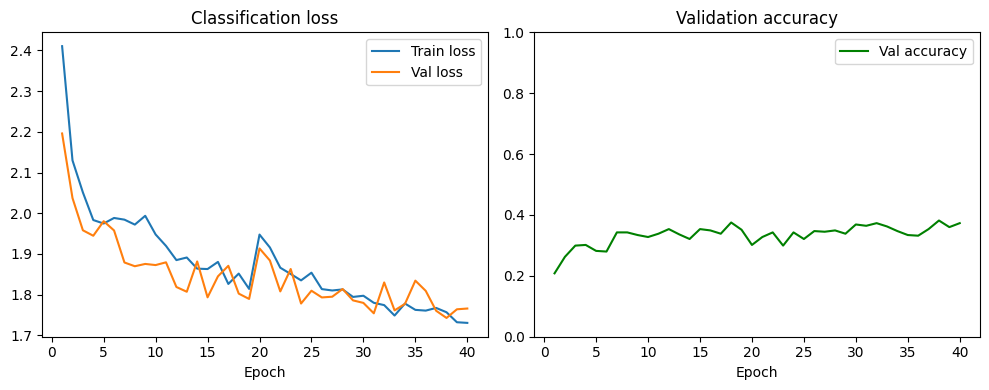

In [16]:
# ====================================
# Step 9.1 – Transfer Learning
# 1) Train a chosen source classifier
# on fma_genre_spectrograms and save the best checkpoint.
# =====================================

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from dataset import SpectrogramDataset, CLASS_MAPPING, torch_train_val_split
from lstm import LSTMBackbone

# If the helper Classifier from earlier steps is not in scope, define a minimal version here.
if "Classifier" not in globals():
    class Classifier(nn.Module):
        def __init__(self, num_classes, backbone):
            super().__init__()
            self.backbone = backbone
            self.is_lstm = isinstance(self.backbone, LSTMBackbone)
            self.output_layer = nn.Linear(self.backbone.feature_size, num_classes)
            self.criterion = nn.CrossEntropyLoss()

        def forward(self, x, targets, lengths):
            feats = self.backbone(x) if not self.is_lstm else self.backbone(x, lengths)
            logits = self.output_layer(feats)
            loss = self.criterion(logits, targets)
            return loss, logits


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
MAX_LENGTH = 150
LR = 1e-4
EPOCHS = 40
MODEL_CHOICE = "lstm"  # choose among: "lstm", "cnn", "ast"

MEL_ROOT = "../input/patreco3-multitask-affective-music/data/fma_genre_spectrograms/"
NUM_CATEGORIES = len(CLASS_MAPPING)


def build_classification_loaders():
    dataset = SpectrogramDataset(
        MEL_ROOT,
        class_mapping=CLASS_MAPPING,
        train=True,
        feat_type="mel",
        max_length=MAX_LENGTH,
    )
    train_loader, val_loader = torch_train_val_split(
        dataset, batch_train=BATCH_SIZE, batch_eval=BATCH_SIZE, val_size=0.2
    )
    xb, yb, lengths = next(iter(train_loader))
    input_shape = xb[0].shape  # (T, F)
    return train_loader, val_loader, input_shape


def build_backbone(name, input_shape):
    if name == "lstm":
        return LSTMBackbone(input_shape[1], rnn_size=128, num_layers=2, bidirectional=True)
    if name == "cnn":
        if "CNNBackbone" not in globals():
            raise RuntimeError("CNNBackbone not found. Run Step 7.1 first.")
        return CNNBackbone(
            input_dims=input_shape,
            in_channels=1,
            filters=[32, 64, 128, 256],
            feature_size=1024,
        )
    if name == "ast":
        if "ASTBackbone" not in globals():
            raise RuntimeError("ASTBackbone not found. Run Step 7.2 first.")
        return ASTBackbone(
            input_fdim=input_shape[1],
            input_tdim=input_shape[0],
            imagenet_pretrain=True,
            model_size="base384",
            feature_size=1024,
        )
    raise ValueError("MODEL_CHOICE must be one of ['lstm', 'cnn', 'ast'].")


def evaluate_classification(model, loader, device=DEVICE):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb, lengths in loader:
            loss, logits = model(
                xb.float().to(device),
                yb.to(device),
                lengths.to(device),
            )
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds.cpu() == yb).sum().item()
            total += len(yb)
    avg_loss = total_loss / len(loader)
    acc = correct / total
    return avg_loss, acc


def train_source_model():
    train_loader, val_loader, input_shape = build_classification_loaders()
    backbone = build_backbone(MODEL_CHOICE, input_shape)
    model = Classifier(NUM_CATEGORIES, backbone).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, best_epoch = -1.0, None, 0
    checkpoint_path = f"transfer_source_{MODEL_CHOICE}.pth"

    for epoch in range(EPOCHS):
        # Train
        model.train()
        running_loss = 0.0
        for xb, yb, lengths in train_loader:
            loss, logits = model(
                xb.float().to(DEVICE),
                yb.to(DEVICE),
                lengths.to(DEVICE),
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        # Validate
        val_loss, val_acc = evaluate_classification(model, val_loader, device=DEVICE)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            best_state = model.state_dict()
            torch.save(best_state, checkpoint_path)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"[{epoch+1:03d}/{EPOCHS}] train_loss={train_loss:.4f} "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best checkpoint: epoch {best_epoch}, val_acc={best_acc:.4f}")
    return model, checkpoint_path, history


source_model, checkpoint_path, clf_history = train_source_model()

# Plot training curves (loss + val accuracy)
epochs_axis = np.arange(1, len(clf_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, clf_history["train_loss"], label="Train loss")
axes[0].plot(epochs_axis, clf_history["val_loss"], label="Val loss")
axes[0].set_title("Classification loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_axis, clf_history["val_acc"], label="Val accuracy", color="green")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()


[01/10] train_loss=0.0928 val_loss=0.0662
[02/10] train_loss=0.0714 val_loss=0.0712
[04/10] train_loss=0.0700 val_loss=0.0644
[06/10] train_loss=0.0624 val_loss=0.0656
[08/10] train_loss=0.0648 val_loss=0.0700
[10/10] train_loss=0.0602 val_loss=0.0628
Fine-tuned on valence: test MSE=0.0629, Spearman=0.2213


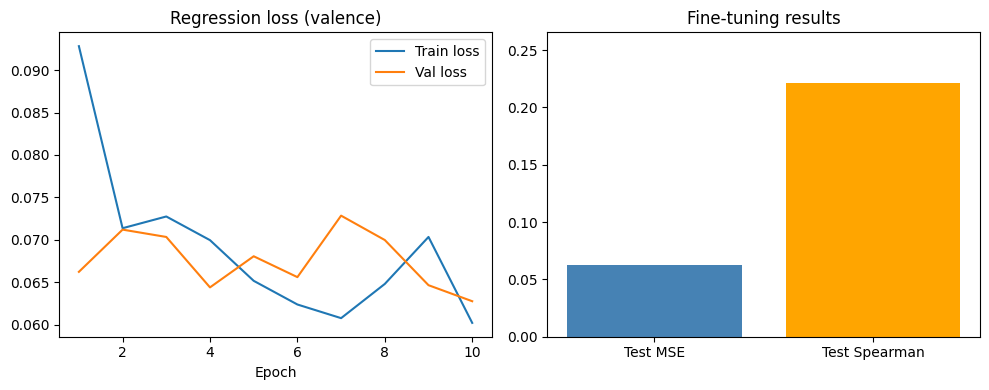

In [17]:
# ====================================
# Step 9.2 – Transfer Learning
# 2) Fine-tune that backbone on a regression
# target(valence/energy/danceability) and evaluate.
# =====================================

import copy
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr


class Regressor(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.is_lstm = isinstance(self.backbone, LSTMBackbone)
        self.output_layer = nn.Linear(self.backbone.feature_size, 1)
        self.criterion = nn.MSELoss()

    def forward(self, x, targets, lengths):
        feats = self.backbone(x) if not self.is_lstm else self.backbone(x, lengths)
        out = self.output_layer(feats)
        loss = self.criterion(out.float(), targets.float())
        return loss, out


REGRESSION_LABELS = {"valence": 1, "energy": 2, "danceability": 3}
REG_TARGET = "valence"  # choose which affective axis to fine-tune on
FINE_TUNE_EPOCHS = 10
FINE_TUNE_LR = 1e-4
MULTITASK_ROOT = "../input/patreco3-multitask-affective-music/data/multitask_dataset"


def build_regression_loaders(target_name, batch_size=BATCH_SIZE, seed=42):
    label_idx = REGRESSION_LABELS[target_name]
    dataset = SpectrogramDataset(
        MULTITASK_ROOT,
        class_mapping=None,
        train=True,
        feat_type="mel",
        max_length=MAX_LENGTH,
        regression_label_index=label_idx,
    )
    indices = np.arange(len(dataset))
    train_idx, temp_idx = np.split(
        np.random.permutation(indices),
        [int(0.7 * len(indices))],
    )
    val_split = int(0.5 * len(temp_idx))
    val_idx, test_idx = temp_idx[:val_split], temp_idx[val_split:]

    def loader(idxs):
        return DataLoader(dataset, batch_size=batch_size, sampler=torch.utils.data.SubsetRandomSampler(idxs))

    train_loader = loader(train_idx)
    val_loader = loader(val_idx)
    test_loader = loader(test_idx)

    xb, _, _ = next(iter(train_loader))
    input_shape = xb[0].shape  # (T, F)
    return train_loader, val_loader, test_loader, input_shape


def load_backbone_weights(backbone, checkpoint_path):
    """Load only backbone.* weights from a saved Classifier checkpoint."""
    state = torch.load(checkpoint_path, map_location=DEVICE)
    backbone_state = {
        k.replace("backbone.", ""): v for k, v in state.items() if k.startswith("backbone.")
    }
    missing, unexpected = backbone.load_state_dict(backbone_state, strict=False)
    if missing:
        print("Missing keys when loading backbone:", missing)
    if unexpected:
        print("Unexpected keys when loading backbone:", unexpected)
    return backbone


def train_regressor(model, train_loader, val_loader, optimizer, epochs=FINE_TUNE_EPOCHS, device=DEVICE):
    best_state, best_val = None, np.inf
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        # train
        model.train()
        running = 0.0
        for xb, yb, lengths in train_loader:
            loss, _ = model(xb.float().to(device), yb.float().unsqueeze(1).to(device), lengths.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_loader)
        # val
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for xb, yb, lengths in val_loader:
                loss, _ = model(xb.float().to(device), yb.float().unsqueeze(1).to(device), lengths.to(device))
                val_running += loss.item()
        val_loss = val_running / len(val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
        if epoch == 0 or (epoch + 1) % 2 == 0:
            print(f"[{epoch+1:02d}/{epochs}] train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def evaluate_regressor(model, loader, device=DEVICE):
    model.eval()
    all_t, all_p = [], []
    with torch.no_grad():
        for xb, yb, lengths in loader:
            _, preds = model(xb.float().to(device), yb.float().unsqueeze(1).to(device), lengths.to(device))
            all_t.append(yb)
            all_p.append(preds.cpu().squeeze(-1))
    targets = torch.cat(all_t).numpy()
    preds = torch.cat(all_p).numpy()
    mse = mean_squared_error(targets, preds)
    corr = spearmanr(targets, preds).correlation
    corr = 0.0 if np.isnan(corr) else corr
    return mse, corr


# Data for fine-tuning
train_reg_loader, val_reg_loader, test_reg_loader, reg_input_shape = build_regression_loaders(REG_TARGET)

# Rebuild backbone and load source weights
transfer_backbone = build_backbone(MODEL_CHOICE, reg_input_shape)
transfer_backbone = load_backbone_weights(transfer_backbone, checkpoint_path)
transfer_model = Regressor(transfer_backbone).to(DEVICE)
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=FINE_TUNE_LR)

# Fine-tune
reg_history = train_regressor(
    transfer_model,
    train_reg_loader,
    val_reg_loader,
    transfer_optimizer,
    epochs=FINE_TUNE_EPOCHS,
    device=DEVICE,
)

# Evaluate on held-out test split
test_mse, test_spearman = evaluate_regressor(transfer_model, test_reg_loader, device=DEVICE)
print(f"Fine-tuned on {REG_TARGET}: test MSE={test_mse:.4f}, Spearman={test_spearman:.4f}")

# Visualize fine-tuning curves and test metrics
epochs_axis = np.arange(1, len(reg_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, reg_history["train_loss"], label="Train loss")
axes[0].plot(epochs_axis, reg_history["val_loss"], label="Val loss")
axes[0].set_title(f"Regression loss ({REG_TARGET})")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].bar(["Test MSE", "Test Spearman"], [test_mse, test_spearman], color=["steelblue", "orange"])
axes[1].set_title("Fine-tuning results")
axes[1].set_ylim(0, max(test_mse, test_spearman) * 1.2 + 1e-6)
plt.tight_layout()
plt.show()


### **Step 10: Training in multiple problems (Multitask Learning)**

---

This step trains a unified multitask regression model using:

- A **shared backbone**  
  (default: the bidirectional 2-layer LSTM from Step 5 with hidden size 128).  
  We can switch `MODEL_CHOICE` to **CNN** or **AST** if we prefer a heavier shared representation.
- We default to the same bidirectional 2-layer LSTM (hidden size 128) because it’s already validated, light on parameters, and quick to train, making multitask experiments faster.
- A **3-output regression head**, one output for each target axis.
- A **custom multitask loss** defined as the sum of the three per-task MSE terms  
  (optionally weighted to account for scale differences).

Training is performed on the **mel-only multitask dataset**,  
padded to `MAX_LENGTH`, with a **70/15/15 train/validation/test split**,  
using **early stopping** based on validation loss.

Evaluation is done on the held-out test split, reporting  
**MSE** and **Spearman correlation** for each of the three tasks.

Plots include the **training/validation loss curves** and a  
**bar chart of test Spearman** for valence, energy, and danceability.


[001/40] train_loss=0.2073 val_loss=0.1518
[005/40] train_loss=0.1336 val_loss=0.1387
[010/40] train_loss=0.1279 val_loss=0.1318
[015/40] train_loss=0.1224 val_loss=0.1436
[020/40] train_loss=0.1097 val_loss=0.1443
[025/40] train_loss=0.1064 val_loss=0.1513
[030/40] train_loss=0.0994 val_loss=0.1447
[035/40] train_loss=0.0992 val_loss=0.1451
[040/40] train_loss=0.0881 val_loss=0.1354

Test loss=0.1400
valence: MSE=0.0652, Spearman=0.3677
energy: MSE=0.0426, Spearman=0.6506
danceability: MSE=0.0270, Spearman=0.4716


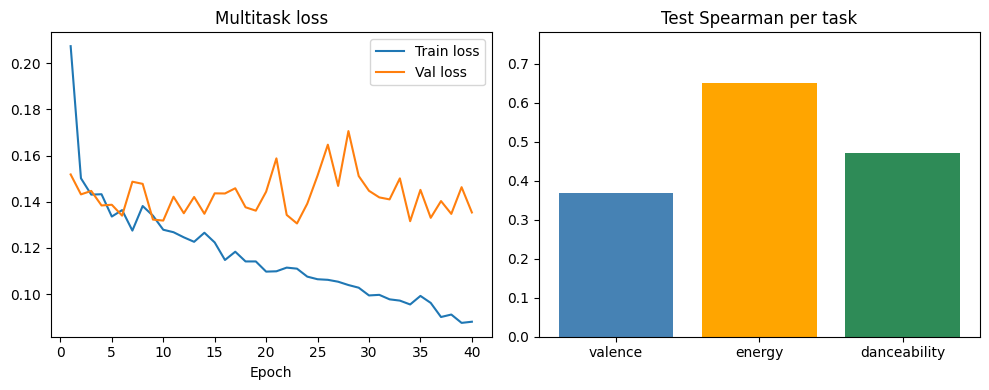

In [18]:
# =================================================================
# Step 10 – Multitask regression (valence, energy, danceability)
# =================================================================

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from lstm import LSTMBackbone


# ------------------------------------------------------------
# Configuration (reuses globals when present)
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = globals().get("BATCH_SIZE", 8)
MAX_LENGTH = globals().get("MAX_LENGTH", 150)
LR = globals().get("LR", 1e-4)
EPOCHS = globals().get("EPOCHS", 40)
MODEL_CHOICE = "lstm"  # options: "lstm", "cnn", "ast"

PARENT_DATA_DIR = globals().get(
    "PARENT_DATA_DIR",
    "../input/patreco3-multitask-affective-music/data/"
)
MULTITASK_ROOT = os.path.join(PARENT_DATA_DIR, "multitask_dataset")
LABELS_PATH = os.path.join(MULTITASK_ROOT, "train_labels.txt")

TASK_NAMES = ["valence", "energy", "danceability"]
TASK_WEIGHTS = torch.tensor([1.0, 1.0, 1.0], device=DEVICE)  # adjust if needed


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
class MultiTaskAffectiveDataset(torch.utils.data.Dataset):
    def __init__(self, labels_csv, data_root, max_length=MAX_LENGTH):
        df = pd.read_csv(labels_csv)
        self.ids = df["Id"].astype(str).tolist()
        self.labels = df[["valence", "energy", "danceability"]].values.astype(np.float32)
        self.data_root = data_root
        self.max_length = max_length

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        track_id = self.ids[idx]
        y = self.labels[idx]
        spec = np.load(os.path.join(self.data_root, "train", f"{track_id}.fused.full.npy"))
        x = spec[:128, :].T  # mel only, shape (T, F)
        length = min(x.shape[0], self.max_length)
        if x.shape[0] > self.max_length:
            x = x[: self.max_length]
        else:
            pad = np.zeros((self.max_length - x.shape[0], x.shape[1]), dtype=np.float32)
            x = np.vstack([x, pad])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y), torch.tensor(length, dtype=torch.long)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
def build_backbone(name, input_shape):
    if name == "lstm":
        return LSTMBackbone(input_shape[1], rnn_size=128, num_layers=2, bidirectional=True)
    if name == "cnn":
        if "CNNBackbone" not in globals():
            raise RuntimeError("CNNBackbone not found. Run Step 7.1 first.")
        return CNNBackbone(
            input_dims=input_shape,
            in_channels=1,
            filters=[32, 64, 128, 256],
            feature_size=1024,
        )
    if name == "ast":
        if "ASTBackbone" not in globals():
            raise RuntimeError("ASTBackbone not found. Run Step 7.2 first.")
        return ASTBackbone(
            input_fdim=input_shape[1],
            input_tdim=input_shape[0],
            imagenet_pretrain=True,
            model_size="base384",
            feature_size=1024,
        )
    raise ValueError("MODEL_CHOICE must be one of ['lstm', 'cnn', 'ast'].")


class MultiTaskRegressor(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.is_lstm = isinstance(self.backbone, LSTMBackbone)
        self.output_layer = nn.Linear(self.backbone.feature_size, 3)
        self.criterion = nn.MSELoss()

    def forward(self, x, targets, lengths):
        feats = self.backbone(x) if not self.is_lstm else self.backbone(x, lengths)
        preds = self.output_layer(feats)
        losses = [self.criterion(preds[:, i], targets[:, i]) for i in range(3)]
        loss = torch.sum(torch.stack(losses) * TASK_WEIGHTS)
        return loss, preds


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def build_loaders():
    ds = MultiTaskAffectiveDataset(LABELS_PATH, MULTITASK_ROOT, max_length=MAX_LENGTH)
    indices = np.arange(len(ds))
    train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, shuffle=True)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, shuffle=True)

    def loader(idxs):
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(idxs))

    train_loader, val_loader, test_loader = loader(train_idx), loader(val_idx), loader(test_idx)
    xb, _, _ = next(iter(train_loader))
    return train_loader, val_loader, test_loader, xb[0].shape  # (T, F)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_t, all_p = 0.0, [], []
    for xb, yb, lengths in loader:
        xb, yb, lengths = xb.to(DEVICE), yb.to(DEVICE), lengths.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        loss, preds = model(xb, yb, lengths)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        all_t.append(yb.cpu()); all_p.append(preds.detach().cpu())
    avg_loss = total_loss / len(loader)
    targets = torch.cat(all_t).numpy()
    preds = torch.cat(all_p).numpy()
    return avg_loss, targets, preds


def evaluate(model, loader):
    loss, targets, preds = run_epoch(model, loader, optimizer=None)
    mse = [mean_squared_error(targets[:, i], preds[:, i]) for i in range(3)]
    corr = [spearmanr(targets[:, i], preds[:, i]).correlation for i in range(3)]
    corr = [0.0 if np.isnan(c) else c for c in corr]
    return loss, mse, corr


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
train_loader, val_loader, test_loader, input_shape = build_loaders()
backbone = build_backbone(MODEL_CHOICE, input_shape)
model = MultiTaskRegressor(backbone).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_state, best_val, history = None, np.inf, {"train": [], "val": []}
for epoch in range(EPOCHS):
    train_loss, _, _ = run_epoch(model, train_loader, optimizer)
    val_loss, _, _ = evaluate(model, val_loader)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    if val_loss < best_val:
        best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"[{epoch+1:03d}/{EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------
test_loss, test_mse, test_corr = evaluate(model, test_loader)
print(f"\nTest loss={test_loss:.4f}")
for i, task in enumerate(TASK_NAMES):
    print(f"{task}: MSE={test_mse[i]:.4f}, Spearman={test_corr[i]:.4f}")

# ------------------------------------------------------------
# Plots: loss curves + Spearman bar
# ------------------------------------------------------------
epochs_axis = np.arange(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, history["train"], label="Train loss")
axes[0].plot(epochs_axis, history["val"], label="Val loss")
axes[0].set_title("Multitask loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].bar(TASK_NAMES, test_corr, color=["steelblue", "orange", "seagreen"])
axes[1].set_title("Test Spearman per task")
axes[1].set_ylim(0, max(test_corr) * 1.2 + 1e-6)
plt.tight_layout()
plt.show()


---

## **AI Usage Declaration**

The **core content and solution** submitted for this project is the product of our team's **independent intellectual effort**.

**AI-based tools were used strictly for supplementary support** by team members, including:

- **Formatting and organizing** markdown cells for improved clarity,
- **Troubleshooting** specific coding issues,
- **Writing code snippets** based on our team's logic and instructions, and
- **Translating content** from Greek to English for documentation and clarity.

At no point was AI used to generate or influence the **core logic**, **design choices**, or **solutions** required for this project.